In [1]:
# ============================================================
# EXPENSE SMS CATEGORY CLASSIFICATION
# FIVE-ALGORITHM COMPARISON
# 14 CLASSES = 13 TRANSACTION CATEGORIES + OTP_REJECT
# ============================================================

import os
import re
import json
import time
import random
import joblib

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import (
    LogisticRegression,
    SGDClassifier
)

from sklearn.svm import LinearSVC

from sklearn.naive_bayes import (
    ComplementNB,
    MultinomialNB
)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support
)

RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print("=" * 70)
print("EXPENSE SMS CLASSIFICATION - SETUP COMPLETE")
print("=" * 70)

EXPENSE SMS CLASSIFICATION - SETUP COMPLETE


In [2]:
# ============================================================
# STEP 2 - PROJECT PATHS
# ============================================================

BASE_DIR = (
    Path.home()
    / "Desktop"
    / "Classification_Model"
)

CSV_FILE = (
    BASE_DIR
    / "Expense_Messages_Dataset_Robust_8400.csv"
)

XLSX_FILE = (
    BASE_DIR
    / "Expense_Messages_Dataset_Robust_8400.xlsx"
)

if CSV_FILE.exists():

    DATA_FILE = CSV_FILE
    DATA_TYPE = "CSV"

elif XLSX_FILE.exists():

    DATA_FILE = XLSX_FILE
    DATA_TYPE = "EXCEL"

else:

    raise FileNotFoundError(
        "Dataset not found inside Desktop/Classification_Model"
    )


MODEL_DIR = BASE_DIR / "models"
REPORT_DIR = BASE_DIR / "reports"
FIGURE_DIR = BASE_DIR / "figures"
SPLIT_DIR = BASE_DIR / "splits"

MODEL_DIR.mkdir(exist_ok=True)
REPORT_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(exist_ok=True)
SPLIT_DIR.mkdir(exist_ok=True)

print("=" * 70)
print("PROJECT PATH CHECK")
print("=" * 70)

print("\nDataset:")
print(DATA_FILE)

print("\nDataset exists:")
print(DATA_FILE.exists())

print("\nModels :", MODEL_DIR)
print("Reports:", REPORT_DIR)
print("Figures:", FIGURE_DIR)
print("Splits :", SPLIT_DIR)

PROJECT PATH CHECK

Dataset:
C:\Users\LENOVO\Desktop\Classification_Model\Expense_Messages_Dataset_Robust_8400.csv

Dataset exists:
True

Models : C:\Users\LENOVO\Desktop\Classification_Model\models
Reports: C:\Users\LENOVO\Desktop\Classification_Model\reports
Figures: C:\Users\LENOVO\Desktop\Classification_Model\figures
Splits : C:\Users\LENOVO\Desktop\Classification_Model\splits


In [3]:
# ============================================================
# STEP 3 - LOAD DATASET
# ============================================================

if DATA_TYPE == "CSV":

    df = pd.read_csv(DATA_FILE)

else:

    df = pd.read_excel(DATA_FILE)


print("=" * 70)
print("DATASET LOADED")
print("=" * 70)

print("\nDataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing SMS:")
print(df["SMS"].isna().sum())

print("\nMissing Category:")
print(df["Category"].isna().sum())

print("\nDuplicate SMS:")
print(df["SMS"].duplicated().sum())

print("\nCategory Distribution:")
print(
    df["Category"]
    .value_counts()
    .sort_index()
)

display(df.head())

DATASET LOADED

Dataset Shape:
(8400, 10)

Columns:
['SMS', 'Amount', 'Transaction_Group', 'Category', 'Is_OTP', 'Data_Source', 'Merchant', 'Channel', 'Status', 'Clean_SMS']

Missing SMS:
0

Missing Category:
0

Duplicate SMS:
0

Category Distribution:
Category
Bills            600
Business         600
Education        600
Entertainment    600
Food             600
Gift             600
Health           600
Investment       600
OTP_REJECT       600
Others           600
Salary           600
Shopping         600
Transport        600
Travel           600
Name: count, dtype: int64


,SMS,Amount,Transaction_Group,Category,Is_OTP,Data_Source,Merchant,Channel,Status,Clean_SMS
0,Your OTP is 770487. Never disclose this code t...,NaN,Non-Transaction,OTP_REJECT,True,SYNTHETIC_V5,NaN,SMS,Security,your otp is <REFERENCE> . never disclose this ...
1,"HNB SMS ALERT: PURCHASE, Debit account:0160***...",15000.0,Expense,Health,False,SYNTHETIC_V4_MERCHANT,Family Pharmacy,Generated,Success,"hnb sms alert: purchase, debit account:0160 <A..."
2,"Dear Sir/Madam, Your A/C 065-2001****11 has be...",15000.0,Expense,Food,False,SYNTHETIC_V4_MERCHANT,Coffee Lounge,Generated,Success,"dear sir/madam, your a/c 065-2001 <ACCOUNT> ha..."
3,"LKR 4,075.00 debited from your account. Reason...",4075.0,Expense,Food,False,SYNTHETIC_V3,City Cafe,Generated,Success,<AMOUNT> debited from your account. reason: me...
4,"Incoming payment of Rs. 1,525.00 received from...",1525.0,Income,Business,False,SYNTHETIC_V5_MERCHANT,Invoice Settlement,CEFT,Success,incoming payment of <AMOUNT> received from inv...


In [4]:
# ============================================================
# STEP 4 - DATASET VALIDATION
# ============================================================

required_columns = [
    "SMS",
    "Category"
]

missing_columns = [
    column
    for column in required_columns
    if column not in df.columns
]

if missing_columns:

    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )


df = df.copy()

df["SMS"] = (
    df["SMS"]
    .astype(str)
    .str.strip()
)

df["Category"] = (
    df["Category"]
    .astype(str)
    .str.strip()
)

df = df[
    (df["SMS"] != "")
    &
    (df["Category"] != "")
].copy()


before = len(df)

df = (
    df.drop_duplicates(
        subset=["SMS"],
        keep="first"
    )
    .reset_index(drop=True)
)

duplicates_removed = (
    before - len(df)
)


print("=" * 70)
print("DATASET VALIDATION COMPLETE")
print("=" * 70)

print("\nFinal rows:")
print(len(df))

print("\nDuplicates removed:")
print(duplicates_removed)

print("\nNumber of output classes:")
print(df["Category"].nunique())

print("\nClasses:")

for category in sorted(
    df["Category"].unique()
):

    print("-", category)

DATASET VALIDATION COMPLETE

Final rows:
8400

Duplicates removed:
0

Number of output classes:
14

Classes:
- Bills
- Business
- Education
- Entertainment
- Food
- Gift
- Health
- Investment
- OTP_REJECT
- Others
- Salary
- Shopping
- Transport
- Travel


In [5]:
# ============================================================
# STEP 5 - VERIFY OTP_REJECT CLASS
# ============================================================

otp_rows = df[
    df["Category"] == "OTP_REJECT"
].copy()

normal_rows = df[
    df["Category"] != "OTP_REJECT"
].copy()

print("=" * 70)
print("OTP_REJECT CLASS CHECK")
print("=" * 70)

print("\nOTP_REJECT rows:")
print(len(otp_rows))

print("\nNormal transaction rows:")
print(len(normal_rows))

if "Is_OTP" in df.columns:

    print("\nOTP Flag Distribution:")
    print(
        df["Is_OTP"]
        .value_counts()
    )

print("\nOTP samples:")

display(
    otp_rows[
        ["SMS", "Category", "Is_OTP"]
    ].head(5)
)

OTP_REJECT CLASS CHECK

OTP_REJECT rows:
600

Normal transaction rows:
7800

OTP Flag Distribution:
Is_OTP
False    7800
True      600
Name: count, dtype: int64

OTP samples:


,SMS,Category,Is_OTP
0,Your OTP is 770487. Never disclose this code t...,OTP_REJECT,True
6,Your verification code is 265056. It expires i...,OTP_REJECT,True
73,Security Alert - Temporary security PIN 836986...,OTP_REJECT,True
74,A verification request was received for the ba...,OTP_REJECT,True
83,Alert: Use authentication code 979827 to compl...,OTP_REJECT,True


In [6]:
# ============================================================
# STEP 6 - DATASET SUMMARY
# ============================================================

dataset_summary = pd.DataFrame({

    "Metric": [
        "Total SMS",
        "Transaction SMS",
        "OTP/Security SMS",
        "Transaction Categories",
        "Total Output Classes",
        "Duplicate SMS Removed"
    ],

    "Value": [
        len(df),
        len(normal_rows),
        len(otp_rows),
        13,
        df["Category"].nunique(),
        duplicates_removed
    ]
})


print("=" * 70)
print("DATASET SUMMARY")
print("=" * 70)

display(dataset_summary)

dataset_summary.to_csv(
    REPORT_DIR / "dataset_summary.csv",
    index=False
)

DATASET SUMMARY


,Metric,Value
0,Total SMS,8400
1,Transaction SMS,7800
2,OTP/Security SMS,600
3,Transaction Categories,13
4,Total Output Classes,14
5,Duplicate SMS Removed,0


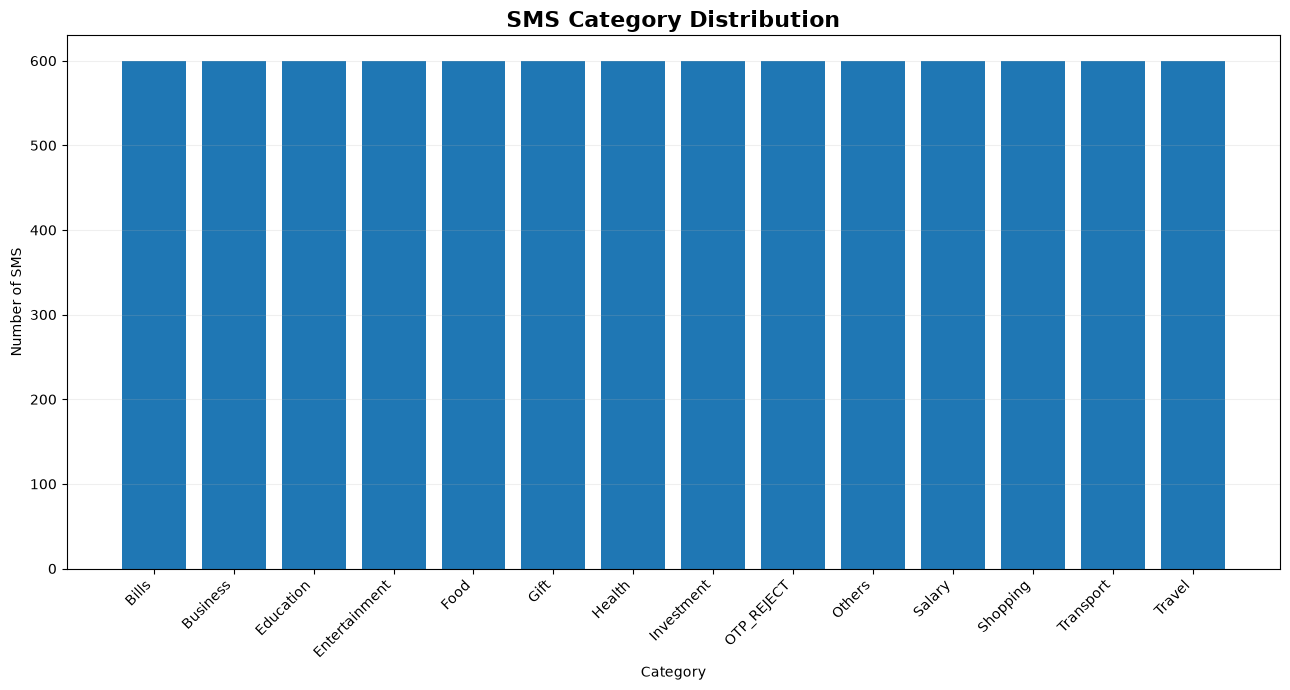

Saved:
C:\Users\LENOVO\Desktop\Classification_Model\figures\01_category_distribution.png


In [7]:
# ============================================================
# STEP 7 - CATEGORY DISTRIBUTION GRAPH
# ============================================================

category_counts = (
    df["Category"]
    .value_counts()
    .sort_index()
)


plt.figure(
    figsize=(13, 7)
)

plt.bar(
    category_counts.index,
    category_counts.values
)

plt.title(
    "SMS Category Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Category"
)

plt.ylabel(
    "Number of SMS"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()

path = (
    FIGURE_DIR
    / "01_category_distribution.png"
)

plt.savefig(
    path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(path)

In [8]:
# ============================================================
# STEP 8 - SMS TEXT NORMALIZATION
# ============================================================

def normalize_sms(text):

    text = str(text).lower()


    # Currency + amount
    text = re.sub(
        r'\b(?:lkr|rs\.?|rs)\s*[\d,]+(?:\.\d+)?',
        ' <AMOUNT> ',
        text,
        flags=re.IGNORECASE
    )


    # Decimal amount
    text = re.sub(
        r'\b\d[\d,]*\.\d{1,2}\b',
        ' <AMOUNT> ',
        text
    )


    # Dates
    text = re.sub(
        r'\b\d{4}-\d{1,2}-\d{1,2}\b',
        ' <DATE> ',
        text
    )

    text = re.sub(
        r'\b\d{1,2}[/-]\d{1,2}[/-]\d{2,4}\b',
        ' <DATE> ',
        text
    )


    # Time
    text = re.sub(
        r'\b\d{1,2}:\d{2}(?::\d{2})?\b',
        ' <TIME> ',
        text
    )


    # Masked account
    text = re.sub(
        r'(?:x|\*){3,}\d*',
        ' <ACCOUNT> ',
        text,
        flags=re.IGNORECASE
    )


    # OTP / reference numbers
    text = re.sub(
        r'\b\d{6,}\b',
        ' <REFERENCE> ',
        text
    )


    # Extra spaces
    text = re.sub(
        r'\s+',
        ' ',
        text
    ).strip()


    return text


df["Clean_SMS"] = (
    df["SMS"]
    .apply(normalize_sms)
)


print("=" * 70)
print("TEXT NORMALIZATION COMPLETE")
print("=" * 70)

for i in range(3):

    print("\nORIGINAL:")
    print(
        df.loc[i, "SMS"]
    )

    print("\nCLEANED:")
    print(
        df.loc[i, "Clean_SMS"]
    )

    print("-" * 70)

TEXT NORMALIZATION COMPLETE

ORIGINAL:
Your OTP is 770487. Never disclose this code to anyone.

CLEANED:
your otp is <REFERENCE> . never disclose this code to anyone.
----------------------------------------------------------------------

ORIGINAL:
HNB SMS ALERT: PURCHASE, Debit account:0160***0899,Location:Family Pharmacy, LK,Amount(Approx.):15,000.00 LKR,Av.Bal:204399.83 LKR,Date:02.08.26,Time:10:31

CLEANED:
hnb sms alert: purchase, debit account:0160 <ACCOUNT> ,location:family pharmacy, lk,amount(approx.): <AMOUNT> <AMOUNT> av.bal: <AMOUNT> <AMOUNT> date: <AMOUNT> .26,time: <TIME>
----------------------------------------------------------------------

ORIGINAL:
Dear Sir/Madam, Your A/C 065-2001****11 has been debited by Rs. 15,000.00 (POS @14:30 12/08/2026 at Coffee Lounge).

CLEANED:
dear sir/madam, your a/c 065-2001 <ACCOUNT> has been debited by <AMOUNT> (pos @ <TIME> <DATE> at coffee lounge).
----------------------------------------------------------------------


In [9]:
# ============================================================
# STEP 9 - TEMPLATE GROUP CREATION
# ============================================================

def create_template_signature(row):

    text = str(
        row["Clean_SMS"]
    ).lower()


    # Replace merchant name
    if "Merchant" in row.index:

        merchant = row.get(
            "Merchant"
        )

        if pd.notna(merchant):

            merchant = (
                str(merchant)
                .strip()
                .lower()
            )

            if merchant:

                text = text.replace(
                    merchant,
                    " <MERCHANT> "
                )


    text = re.sub(
        r'\s+',
        ' ',
        text
    ).strip()


    return (
        str(row["Category"])
        +
        "__"
        +
        text
    )


df["Template_Group"] = (
    df.apply(
        create_template_signature,
        axis=1
    )
)


print("=" * 70)
print("TEMPLATE GROUPS CREATED")
print("=" * 70)

print("\nTotal rows:")
print(len(df))

print("\nUnique Template Groups:")
print(
    df["Template_Group"]
    .nunique()
)

TEMPLATE GROUPS CREATED

Total rows:
8400

Unique Template Groups:
2454


In [10]:
# ============================================================
# STEP 10 - STRATIFIED TRAIN / VALIDATION / TEST SPLIT
# 70% TRAIN
# 15% VALIDATION
# 15% TEST
# ============================================================

from sklearn.model_selection import train_test_split


# First split:
# 70% Train
# 30% Temporary
train_df, temp_df = train_test_split(

    df,

    test_size=0.30,

    stratify=df["Category"],

    random_state=RANDOM_STATE
)


# Second split:
# 15% Validation
# 15% Test
val_df, test_df = train_test_split(

    temp_df,

    test_size=0.50,

    stratify=temp_df["Category"],

    random_state=RANDOM_STATE
)


train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)


print("=" * 70)
print("STRATIFIED DATA SPLIT COMPLETE")
print("=" * 70)

print("\nTraining samples:")
print(len(train_df))

print("\nValidation samples:")
print(len(val_df))

print("\nTesting samples:")
print(len(test_df))

STRATIFIED DATA SPLIT COMPLETE

Training samples:
5880

Validation samples:
1260

Testing samples:
1260


In [11]:
# ============================================================
# STEP 11 - TEMPLATE LEAKAGE CHECK
# ============================================================

train_groups = set(
    train_df["Template_Group"]
)

val_groups = set(
    val_df["Template_Group"]
)

test_groups = set(
    test_df["Template_Group"]
)


train_val_overlap = (
    train_groups
    &
    val_groups
)

train_test_overlap = (
    train_groups
    &
    test_groups
)

val_test_overlap = (
    val_groups
    &
    test_groups
)


print("=" * 70)
print("TEMPLATE LEAKAGE CHECK")
print("=" * 70)

print(
    "\nTrain vs Validation:",
    len(train_val_overlap)
)

print(
    "Train vs Test:",
    len(train_test_overlap)
)

print(
    "Validation vs Test:",
    len(val_test_overlap)
)

TEMPLATE LEAKAGE CHECK

Train vs Validation: 546
Train vs Test: 558
Validation vs Test: 294


In [12]:
# ============================================================
# STEP 12 - SPLIT CATEGORY DISTRIBUTION
# ============================================================

split_distribution = pd.DataFrame({

    "Train":
        train_df[
            "Category"
        ].value_counts(),

    "Validation":
        val_df[
            "Category"
        ].value_counts(),

    "Test":
        test_df[
            "Category"
        ].value_counts()

}).fillna(0).astype(int)


split_distribution = (
    split_distribution
    .sort_index()
)


print("=" * 70)
print("CLASS DISTRIBUTION BY SPLIT")
print("=" * 70)

display(
    split_distribution
)


split_distribution.to_csv(
    REPORT_DIR
    / "split_class_distribution.csv"
)

CLASS DISTRIBUTION BY SPLIT


,Train,Validation,Test
Category,,,
Bills,420,90,90
Business,420,90,90
Education,420,90,90
Entertainment,420,90,90
Food,420,90,90
Gift,420,90,90
Health,420,90,90
Investment,420,90,90
OTP_REJECT,420,90,90


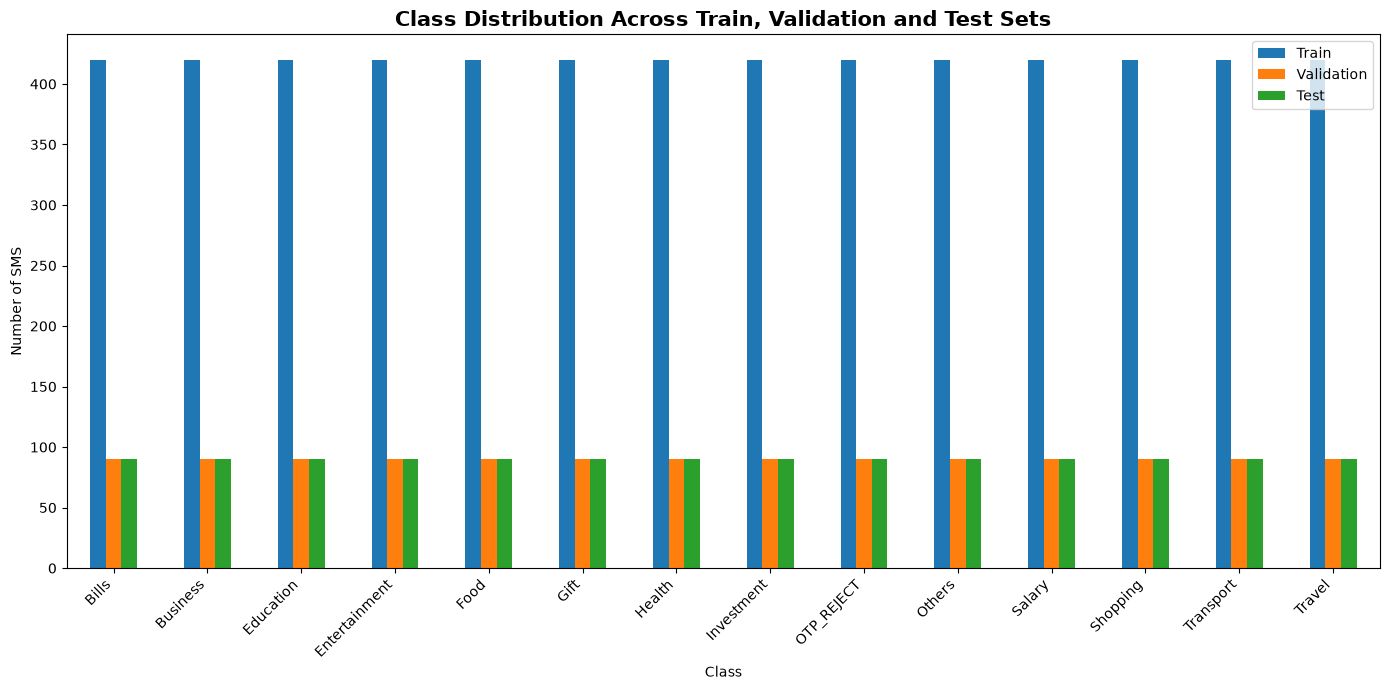

In [13]:
# ============================================================
# STEP 13 - SPLIT DISTRIBUTION GRAPH
# ============================================================

split_distribution.plot(

    kind="bar",

    figsize=(14, 7)
)


plt.title(
    "Class Distribution Across Train, Validation and Test Sets",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "Class"
)

plt.ylabel(
    "Number of SMS"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

path = (
    FIGURE_DIR
    / "02_split_distribution.png"
)

plt.savefig(
    path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [14]:
# ============================================================
# STEP 14 - SAVE SPLITS
# ============================================================

train_df.to_csv(
    SPLIT_DIR
    / "train_split.csv",
    index=False
)

val_df.to_csv(
    SPLIT_DIR
    / "validation_split.csv",
    index=False
)

test_df.to_csv(
    SPLIT_DIR
    / "test_split.csv",
    index=False
)

print("Train / Validation / Test splits saved successfully.")

Train / Validation / Test splits saved successfully.


In [15]:
# ============================================================
# STEP 15 - TF-IDF CONFIGURATION
# ============================================================

def create_tfidf():

    return TfidfVectorizer(

        lowercase=True,

        strip_accents="unicode",

        ngram_range=(1, 2),

        min_df=1,

        sublinear_tf=True,

        max_features=30000
    )


print("TF-IDF configuration ready.")

TF-IDF configuration ready.


In [16]:
# ============================================================
# STEP 16 - DEFINE FIVE TEXT CLASSIFICATION MODELS
# ============================================================

models = {


    # 1. LOGISTIC REGRESSION
    "Logistic Regression":

        Pipeline([

            (
                "tfidf",
                create_tfidf()
            ),

            (
                "classifier",

                LogisticRegression(

                    max_iter=4000,

                    class_weight="balanced",

                    random_state=RANDOM_STATE
                )
            )
        ]),


    # 2. LINEAR SVM
    "Linear SVM":

        Pipeline([

            (
                "tfidf",
                create_tfidf()
            ),

            (
                "classifier",

                LinearSVC(

                    class_weight="balanced",

                    random_state=RANDOM_STATE
                )
            )
        ]),


    # 3. COMPLEMENT NAIVE BAYES
    "Complement Naive Bayes":

        Pipeline([

            (
                "tfidf",
                create_tfidf()
            ),

            (
                "classifier",

                ComplementNB(
                    alpha=1.0
                )
            )
        ]),


    # 4. MULTINOMIAL NAIVE BAYES
    "Multinomial Naive Bayes":

        Pipeline([

            (
                "tfidf",
                create_tfidf()
            ),

            (
                "classifier",

                MultinomialNB(
                    alpha=1.0
                )
            )
        ]),


    # 5. SGD CLASSIFIER
    "SGD Classifier":

        Pipeline([

            (
                "tfidf",
                create_tfidf()
            ),

            (
                "classifier",

                SGDClassifier(

                    loss="modified_huber",

                    class_weight="balanced",

                    max_iter=3000,

                    tol=1e-4,

                    random_state=RANDOM_STATE
                )
            )
        ])
}


print("=" * 70)
print("FIVE CLASSIFICATION MODELS READY")
print("=" * 70)

for i, model_name in enumerate(
    models.keys(),
    start=1
):

    print(
        f"{i}. {model_name}"
    )

FIVE CLASSIFICATION MODELS READY
1. Logistic Regression
2. Linear SVM
3. Complement Naive Bayes
4. Multinomial Naive Bayes
5. SGD Classifier


In [17]:
# ============================================================
# STEP 17 - TRAIN ALL FIVE MODELS
# ============================================================

trained_models = {}

validation_rows = []

validation_predictions = {}


for name, model in models.items():

    print(
        "\n"
        + "=" * 70
    )

    print(
        "TRAINING:",
        name
    )

    print(
        "=" * 70
    )


    start_time = (
        time.time()
    )


    model.fit(

        train_df[
            "Clean_SMS"
        ],

        train_df[
            "Category"
        ]
    )


    training_time = (
        time.time()
        -
        start_time
    )


    trained_models[
        name
    ] = model


    train_pred = (
        model.predict(
            train_df[
                "Clean_SMS"
            ]
        )
    )


    val_pred = (
        model.predict(
            val_df[
                "Clean_SMS"
            ]
        )
    )


    validation_predictions[
        name
    ] = val_pred


    train_accuracy = (
        accuracy_score(
            train_df["Category"],
            train_pred
        )
    )


    val_accuracy = (
        accuracy_score(
            val_df["Category"],
            val_pred
        )
    )


    macro_precision, \
    macro_recall, \
    macro_f1, _ = (

        precision_recall_fscore_support(

            val_df[
                "Category"
            ],

            val_pred,

            average="macro",

            zero_division=0
        )
    )


    weighted_precision, \
    weighted_recall, \
    weighted_f1, _ = (

        precision_recall_fscore_support(

            val_df[
                "Category"
            ],

            val_pred,

            average="weighted",

            zero_division=0
        )
    )


    validation_rows.append({

        "Algorithm":
            name,

        "Train Accuracy":
            train_accuracy * 100,

        "Validation Accuracy":
            val_accuracy * 100,

        "Macro Precision":
            macro_precision * 100,

        "Macro Recall":
            macro_recall * 100,

        "Macro F1":
            macro_f1 * 100,

        "Weighted Precision":
            weighted_precision * 100,

        "Weighted Recall":
            weighted_recall * 100,

        "Weighted F1":
            weighted_f1 * 100,

        "Validation Error Rate":
            (1 - val_accuracy) * 100,

        "Training Time (sec)":
            training_time
    })


    print(
        f"Validation Accuracy: "
        f"{val_accuracy * 100:.2f}%"
    )

    print(
        f"Macro F1: "
        f"{macro_f1 * 100:.2f}%"
    )


TRAINING: Logistic Regression
Validation Accuracy: 99.52%
Macro F1: 99.52%

TRAINING: Linear SVM
Validation Accuracy: 99.84%
Macro F1: 99.84%

TRAINING: Complement Naive Bayes
Validation Accuracy: 99.52%
Macro F1: 99.52%

TRAINING: Multinomial Naive Bayes
Validation Accuracy: 98.25%
Macro F1: 98.26%

TRAINING: SGD Classifier
Validation Accuracy: 99.84%
Macro F1: 99.84%


In [18]:
# ============================================================
# STEP 18 - VALIDATION COMPARISON
# ============================================================

validation_results_df = (
    pd.DataFrame(
        validation_rows
    )
)


validation_results_df = (

    validation_results_df

    .sort_values(

        by=[
            "Macro F1",
            "Validation Accuracy"
        ],

        ascending=False
    )

    .reset_index(
        drop=True
    )
)


print("=" * 70)
print("VALIDATION MODEL COMPARISON")
print("=" * 70)


display(
    validation_results_df.round(2)
)


validation_results_df.to_csv(
    REPORT_DIR
    / "validation_model_comparison.csv",
    index=False
)

VALIDATION MODEL COMPARISON


,Algorithm,Train Accuracy,Validation Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1,Validation Error Rate,Training Time (sec)
0,Linear SVM,100.00,99.84,99.84,99.84,99.84,99.84,99.84,99.84,0.16,1.58
1,SGD Classifier,100.00,99.84,99.84,99.84,99.84,99.84,99.84,99.84,0.16,0.68
2,Logistic Regression,99.95,99.52,99.53,99.52,99.52,99.53,99.52,99.52,0.48,2.03
3,Complement Naive Bayes,99.81,99.52,99.54,99.52,99.52,99.54,99.52,99.52,0.48,0.45
4,Multinomial Naive Bayes,99.35,98.25,98.33,98.25,98.26,98.33,98.25,98.26,1.75,0.44


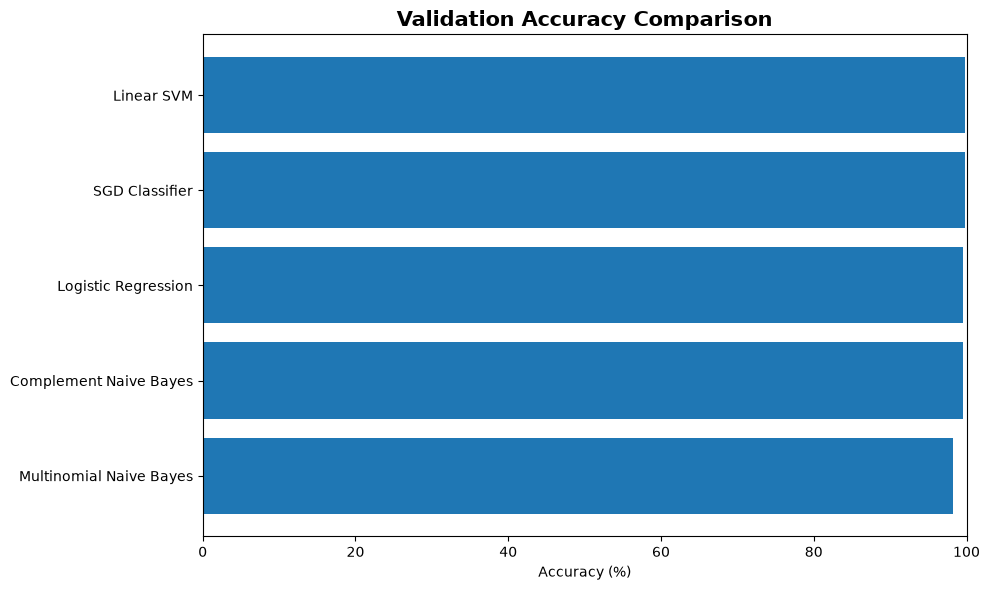

In [19]:
# ============================================================
# STEP 19 - VALIDATION ACCURACY GRAPH
# ============================================================

plot_df = (
    validation_results_df
    .sort_values(
        "Validation Accuracy"
    )
)


plt.figure(
    figsize=(10, 6)
)


plt.barh(

    plot_df["Algorithm"],

    plot_df[
        "Validation Accuracy"
    ]
)


plt.title(
    "Validation Accuracy Comparison",
    fontsize=15,
    fontweight="bold"
)


plt.xlabel(
    "Accuracy (%)"
)


plt.xlim(
    0,
    100
)


plt.tight_layout()


path = (
    FIGURE_DIR
    / "03_validation_accuracy.png"
)


plt.savefig(
    path,
    dpi=300,
    bbox_inches="tight"
)


plt.show()

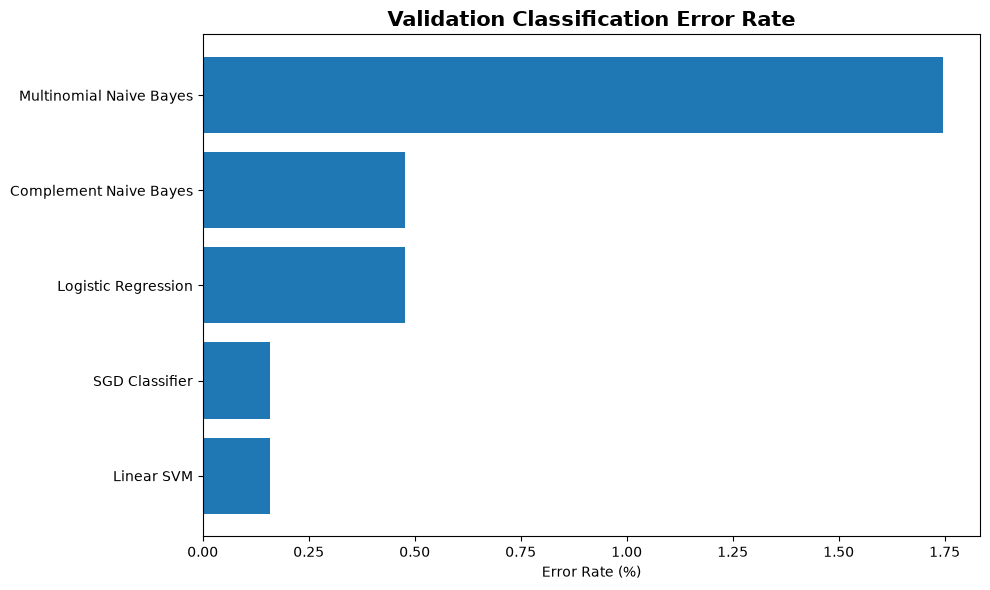

In [20]:
# ============================================================
# STEP 20 - VALIDATION ERROR RATE
# ERROR RATE = 100 - ACCURACY
# ============================================================

plot_df = (
    validation_results_df
    .sort_values(
        "Validation Error Rate"
    )
)


plt.figure(
    figsize=(10, 6)
)


plt.barh(

    plot_df["Algorithm"],

    plot_df[
        "Validation Error Rate"
    ]
)


plt.title(
    "Validation Classification Error Rate",
    fontsize=15,
    fontweight="bold"
)


plt.xlabel(
    "Error Rate (%)"
)


plt.tight_layout()


path = (
    FIGURE_DIR
    / "04_validation_error_rate.png"
)


plt.savefig(
    path,
    dpi=300,
    bbox_inches="tight"
)


plt.show()

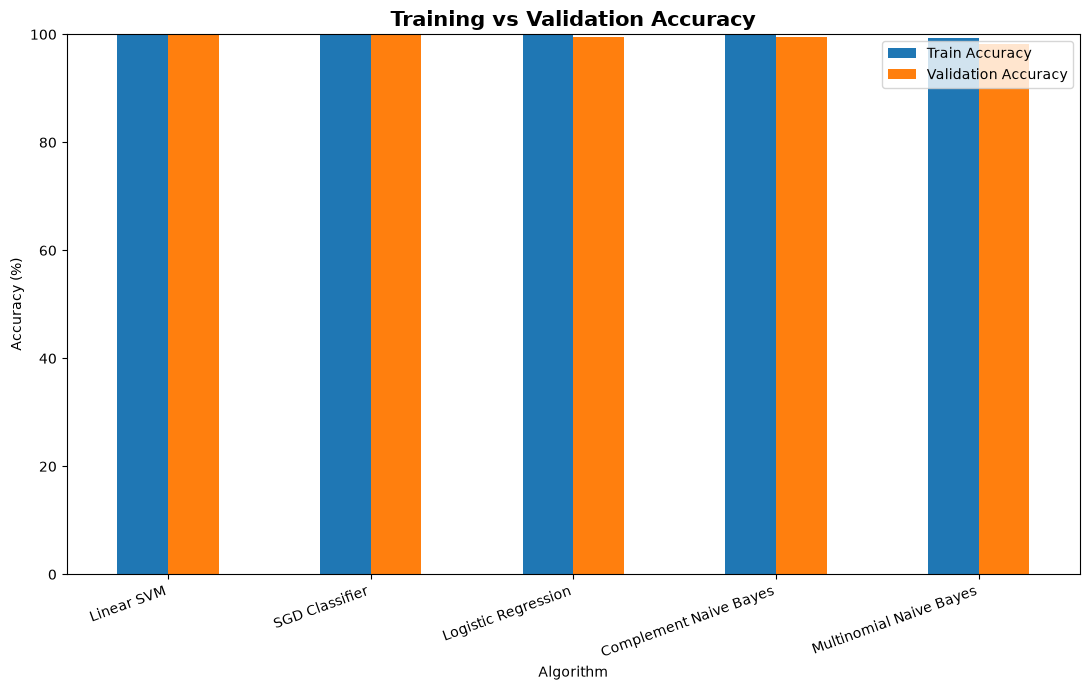

In [21]:
# ============================================================
# STEP 21 - TRAIN VS VALIDIDATION ACCURACY
# ============================================================

train_val_df = (

    validation_results_df

    .set_index(
        "Algorithm"
    )

    [
        [
            "Train Accuracy",
            "Validation Accuracy"
        ]
    ]
)


train_val_df.plot(

    kind="bar",

    figsize=(11, 7)
)


plt.title(
    "Training vs Validation Accuracy",
    fontsize=15,
    fontweight="bold"
)


plt.ylabel(
    "Accuracy (%)"
)


plt.ylim(
    0,
    100
)


plt.xticks(
    rotation=20,
    ha="right"
)


plt.tight_layout()


path = (
    FIGURE_DIR
    / "05_train_vs_validation_accuracy.png"
)


plt.savefig(
    path,
    dpi=300,
    bbox_inches="tight"
)


plt.show()

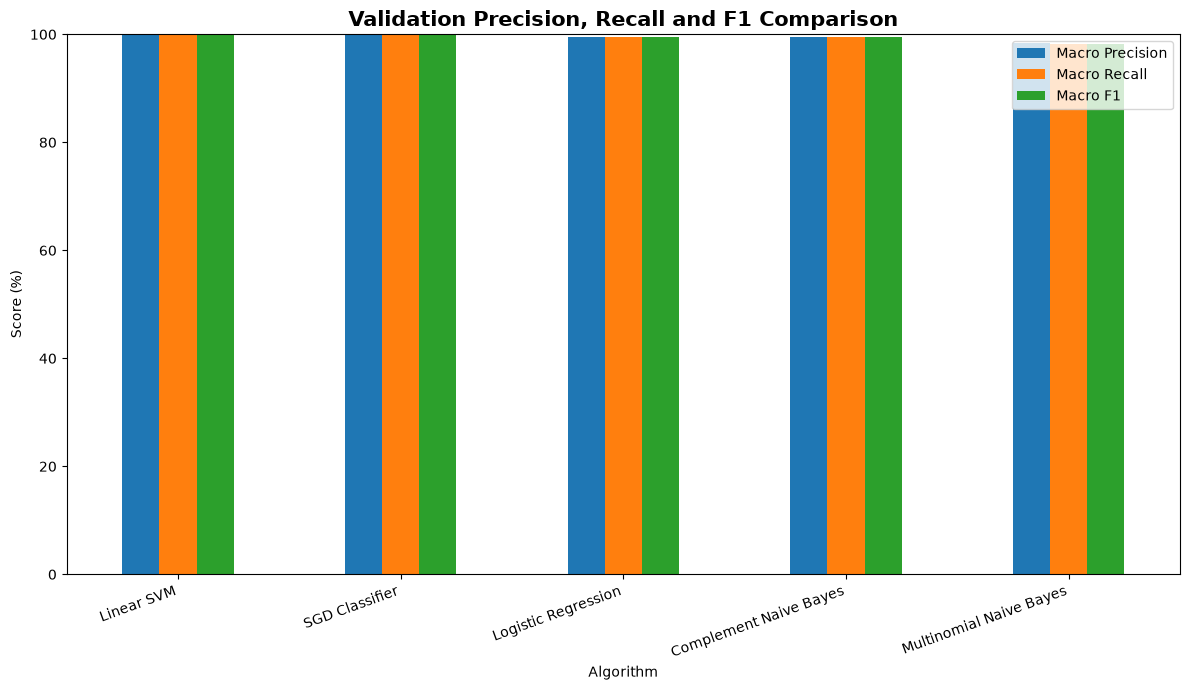

In [22]:
# ============================================================
# STEP 22 - VALIDATION PRECISION / RECALL / F1 GRAPH
# ============================================================

metric_plot = (

    validation_results_df

    .set_index(
        "Algorithm"
    )

    [
        [
            "Macro Precision",
            "Macro Recall",
            "Macro F1"
        ]
    ]
)


metric_plot.plot(

    kind="bar",

    figsize=(12, 7)
)


plt.title(
    "Validation Precision, Recall and F1 Comparison",
    fontsize=15,
    fontweight="bold"
)


plt.ylabel(
    "Score (%)"
)


plt.ylim(
    0,
    100
)


plt.xticks(
    rotation=20,
    ha="right"
)


plt.tight_layout()


path = (
    FIGURE_DIR
    / "06_validation_precision_recall_f1.png"
)


plt.savefig(
    path,
    dpi=300,
    bbox_inches="tight"
)


plt.show()

In [23]:
# ============================================================
# STEP 23 - SELECT BEST MODEL
# ============================================================

best_validation_row = (
    validation_results_df
    .iloc[0]
)


best_model_name = (
    best_validation_row[
        "Algorithm"
    ]
)


best_model = (
    trained_models[
        best_model_name
    ]
)


print("=" * 70)
print("BEST MODEL SELECTED FROM VALIDATION RESULTS")
print("=" * 70)

print(
    "\nBest Algorithm:",
    best_model_name
)

print(
    "Validation Accuracy:",
    f"{best_validation_row['Validation Accuracy']:.2f}%"
)

print(
    "Macro F1:",
    f"{best_validation_row['Macro F1']:.2f}%"
)

print(
    "Weighted F1:",
    f"{best_validation_row['Weighted F1']:.2f}%"
)

BEST MODEL SELECTED FROM VALIDATION RESULTS

Best Algorithm: Linear SVM
Validation Accuracy: 99.84%
Macro F1: 99.84%
Weighted F1: 99.84%


In [24]:
# ============================================================
# STEP 24 - FINAL TEST EVALUATION
# ============================================================

test_rows = []

test_predictions = {}

test_reports = {}


for name, model in (
    trained_models.items()
):

    y_true = (
        test_df[
            "Category"
        ]
    )


    y_pred = (
        model.predict(
            test_df[
                "Clean_SMS"
            ]
        )
    )


    test_predictions[
        name
    ] = y_pred


    accuracy = (
        accuracy_score(
            y_true,
            y_pred
        )
    )


    report = (
        classification_report(

            y_true,

            y_pred,

            output_dict=True,

            zero_division=0
        )
    )


    test_reports[
        name
    ] = report


    test_rows.append({

        "Algorithm":
            name,

        "Test Accuracy":
            accuracy * 100,

        "Macro Precision":
            report[
                "macro avg"
            ]["precision"] * 100,

        "Macro Recall":
            report[
                "macro avg"
            ]["recall"] * 100,

        "Macro F1":
            report[
                "macro avg"
            ]["f1-score"] * 100,

        "Weighted Precision":
            report[
                "weighted avg"
            ]["precision"] * 100,

        "Weighted Recall":
            report[
                "weighted avg"
            ]["recall"] * 100,

        "Weighted F1":
            report[
                "weighted avg"
            ]["f1-score"] * 100,

        "Test Error Rate":
            (1 - accuracy) * 100
    })


test_results_df = (
    pd.DataFrame(
        test_rows
    )
)


print("=" * 70)
print("FINAL HELD-OUT TEST RESULTS")
print("=" * 70)


display(

    test_results_df

    .sort_values(
        "Test Accuracy",
        ascending=False
    )

    .round(2)
)


test_results_df.to_csv(
    REPORT_DIR
    / "final_test_results.csv",
    index=False
)

FINAL HELD-OUT TEST RESULTS


,Algorithm,Test Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1,Test Error Rate
1,Linear SVM,100.00,100.00,100.00,100.00,100.00,100.00,100.00,0.00
4,SGD Classifier,100.00,100.00,100.00,100.00,100.00,100.00,100.00,0.00
0,Logistic Regression,99.92,99.92,99.92,99.92,99.92,99.92,99.92,0.08
2,Complement Naive Bayes,99.92,99.92,99.92,99.92,99.92,99.92,99.92,0.08
3,Multinomial Naive Bayes,98.89,98.94,98.89,98.90,98.94,98.89,98.90,1.11


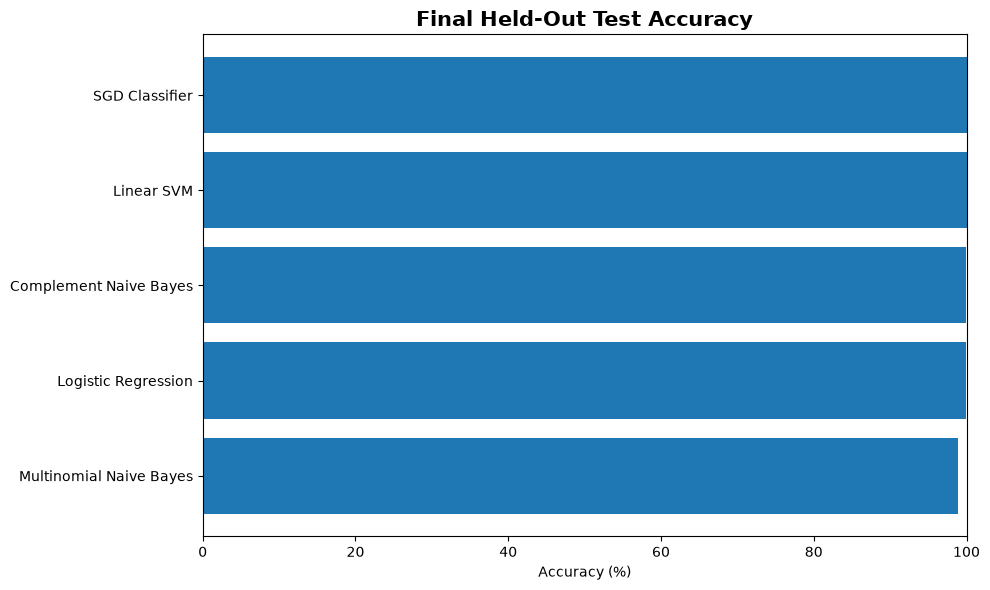

In [25]:
# ============================================================
# STEP 25 - TEST ACCURACY GRAPH
# ============================================================

plot_df = (
    test_results_df
    .sort_values(
        "Test Accuracy"
    )
)


plt.figure(
    figsize=(10, 6)
)


plt.barh(

    plot_df["Algorithm"],

    plot_df[
        "Test Accuracy"
    ]
)


plt.title(
    "Final Held-Out Test Accuracy",
    fontsize=15,
    fontweight="bold"
)


plt.xlabel(
    "Accuracy (%)"
)


plt.xlim(
    0,
    100
)


plt.tight_layout()


path = (
    FIGURE_DIR
    / "07_test_accuracy.png"
)


plt.savefig(
    path,
    dpi=300,
    bbox_inches="tight"
)


plt.show()

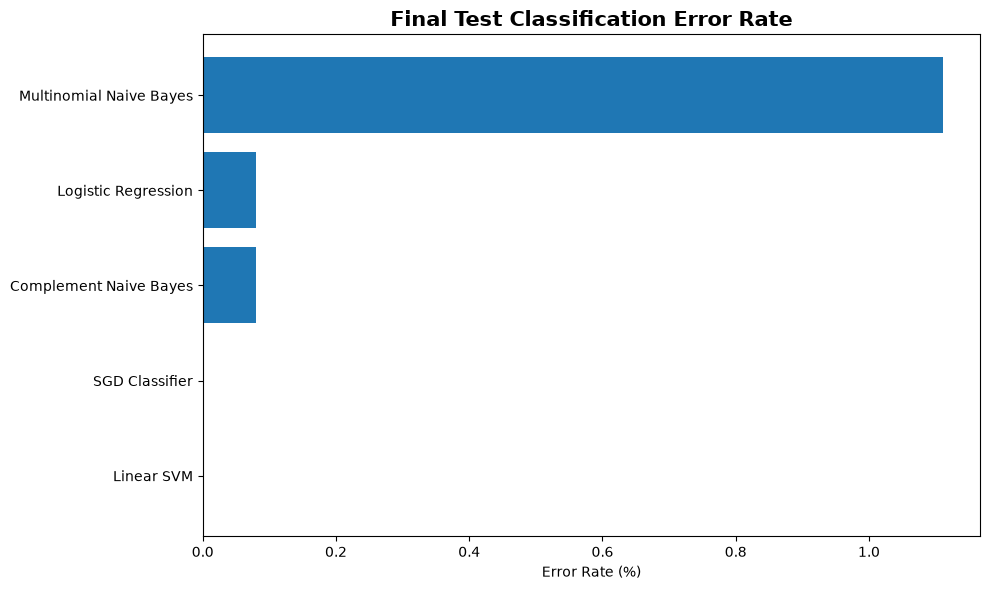

In [26]:
# ============================================================
# STEP 26 - TEST ERROR RATE
# ============================================================

plot_df = (
    test_results_df
    .sort_values(
        "Test Error Rate"
    )
)


plt.figure(
    figsize=(10, 6)
)


plt.barh(

    plot_df[
        "Algorithm"
    ],

    plot_df[
        "Test Error Rate"
    ]
)


plt.title(
    "Final Test Classification Error Rate",
    fontsize=15,
    fontweight="bold"
)


plt.xlabel(
    "Error Rate (%)"
)


plt.tight_layout()


path = (
    FIGURE_DIR
    / "08_test_error_rate.png"
)


plt.savefig(
    path,
    dpi=300,
    bbox_inches="tight"
)


plt.show()

In [27]:
# ============================================================
# STEP 27 - CLASSIFICATION REPORTS
# ============================================================

for name, report in (
    test_reports.items()
):

    print(
        "\n"
        + "=" * 70
    )

    print(
        name.upper()
    )

    print(
        "=" * 70
    )


    report_df = (

        pd.DataFrame(
            report
        )

        .transpose()
    )


    display(
        report_df.round(4)
    )


    safe_name = (

        name.lower()

        .replace(
            " ",
            "_"
        )
    )


    report_df.to_csv(

        REPORT_DIR
        /
        f"{safe_name}_classification_report.csv"
    )


LOGISTIC REGRESSION


,precision,recall,f1-score,support
Bills,1.0000,1.0000,1.0000,90.0000
Business,1.0000,1.0000,1.0000,90.0000
Education,1.0000,0.9889,0.9944,90.0000
Entertainment,1.0000,1.0000,1.0000,90.0000
Food,1.0000,1.0000,1.0000,90.0000
Gift,1.0000,1.0000,1.0000,90.0000
Health,1.0000,1.0000,1.0000,90.0000
Investment,1.0000,1.0000,1.0000,90.0000
OTP_REJECT,1.0000,1.0000,1.0000,90.0000
Others,1.0000,1.0000,1.0000,90.0000



LINEAR SVM


,precision,recall,f1-score,support
Bills,1.0,1.0,1.0,90.0
Business,1.0,1.0,1.0,90.0
Education,1.0,1.0,1.0,90.0
Entertainment,1.0,1.0,1.0,90.0
Food,1.0,1.0,1.0,90.0
Gift,1.0,1.0,1.0,90.0
Health,1.0,1.0,1.0,90.0
Investment,1.0,1.0,1.0,90.0
OTP_REJECT,1.0,1.0,1.0,90.0
Others,1.0,1.0,1.0,90.0



COMPLEMENT NAIVE BAYES


,precision,recall,f1-score,support
Bills,1.0000,1.0000,1.0000,90.0000
Business,0.9890,1.0000,0.9945,90.0000
Education,1.0000,1.0000,1.0000,90.0000
Entertainment,1.0000,1.0000,1.0000,90.0000
Food,1.0000,1.0000,1.0000,90.0000
Gift,1.0000,1.0000,1.0000,90.0000
Health,1.0000,1.0000,1.0000,90.0000
Investment,1.0000,1.0000,1.0000,90.0000
OTP_REJECT,1.0000,1.0000,1.0000,90.0000
Others,1.0000,0.9889,0.9944,90.0000



MULTINOMIAL NAIVE BAYES


,precision,recall,f1-score,support
Bills,1.0000,0.9556,0.9773,90.0000
Business,1.0000,1.0000,1.0000,90.0000
Education,1.0000,0.9889,0.9944,90.0000
Entertainment,0.9677,1.0000,0.9836,90.0000
Food,0.9889,0.9889,0.9889,90.0000
Gift,1.0000,1.0000,1.0000,90.0000
Health,1.0000,0.9667,0.9831,90.0000
Investment,0.9890,1.0000,0.9945,90.0000
OTP_REJECT,1.0000,1.0000,1.0000,90.0000
Others,0.9888,0.9778,0.9832,90.0000



SGD CLASSIFIER


,precision,recall,f1-score,support
Bills,1.0,1.0,1.0,90.0
Business,1.0,1.0,1.0,90.0
Education,1.0,1.0,1.0,90.0
Entertainment,1.0,1.0,1.0,90.0
Food,1.0,1.0,1.0,90.0
Gift,1.0,1.0,1.0,90.0
Health,1.0,1.0,1.0,90.0
Investment,1.0,1.0,1.0,90.0
OTP_REJECT,1.0,1.0,1.0,90.0
Others,1.0,1.0,1.0,90.0


In [28]:
# ============================================================
# STEP 28 - OTP_REJECT PERFORMANCE
# ============================================================

otp_performance_rows = []


for name, report in (
    test_reports.items()
):

    otp_metrics = (
        report[
            "OTP_REJECT"
        ]
    )


    otp_performance_rows.append({

        "Algorithm":
            name,

        "OTP Precision":
            otp_metrics[
                "precision"
            ] * 100,

        "OTP Recall":
            otp_metrics[
                "recall"
            ] * 100,

        "OTP F1":
            otp_metrics[
                "f1-score"
            ] * 100,

        "OTP Test Support":
            int(
                otp_metrics[
                    "support"
                ]
            )
    })


otp_performance_df = (
    pd.DataFrame(
        otp_performance_rows
    )
)


print("=" * 70)
print("OTP_REJECT CLASS PERFORMANCE")
print("=" * 70)


display(
    otp_performance_df.round(2)
)


otp_performance_df.to_csv(

    REPORT_DIR
    / "otp_reject_performance.csv",

    index=False
)

OTP_REJECT CLASS PERFORMANCE


,Algorithm,OTP Precision,OTP Recall,OTP F1,OTP Test Support
0,Logistic Regression,100.0,100.0,100.0,90
1,Linear SVM,100.0,100.0,100.0,90
2,Complement Naive Bayes,100.0,100.0,100.0,90
3,Multinomial Naive Bayes,100.0,100.0,100.0,90
4,SGD Classifier,100.0,100.0,100.0,90


In [29]:
# ============================================================
# STEP 28 - OTP_REJECT PERFORMANCE
# ============================================================

otp_performance_rows = []


for name, report in (
    test_reports.items()
):

    otp_metrics = (
        report[
            "OTP_REJECT"
        ]
    )


    otp_performance_rows.append({

        "Algorithm":
            name,

        "OTP Precision":
            otp_metrics[
                "precision"
            ] * 100,

        "OTP Recall":
            otp_metrics[
                "recall"
            ] * 100,

        "OTP F1":
            otp_metrics[
                "f1-score"
            ] * 100,

        "OTP Test Support":
            int(
                otp_metrics[
                    "support"
                ]
            )
    })


otp_performance_df = (
    pd.DataFrame(
        otp_performance_rows
    )
)


print("=" * 70)
print("OTP_REJECT CLASS PERFORMANCE")
print("=" * 70)


display(
    otp_performance_df.round(2)
)


otp_performance_df.to_csv(

    REPORT_DIR
    / "otp_reject_performance.csv",

    index=False
)

OTP_REJECT CLASS PERFORMANCE


,Algorithm,OTP Precision,OTP Recall,OTP F1,OTP Test Support
0,Logistic Regression,100.0,100.0,100.0,90
1,Linear SVM,100.0,100.0,100.0,90
2,Complement Naive Bayes,100.0,100.0,100.0,90
3,Multinomial Naive Bayes,100.0,100.0,100.0,90
4,SGD Classifier,100.0,100.0,100.0,90


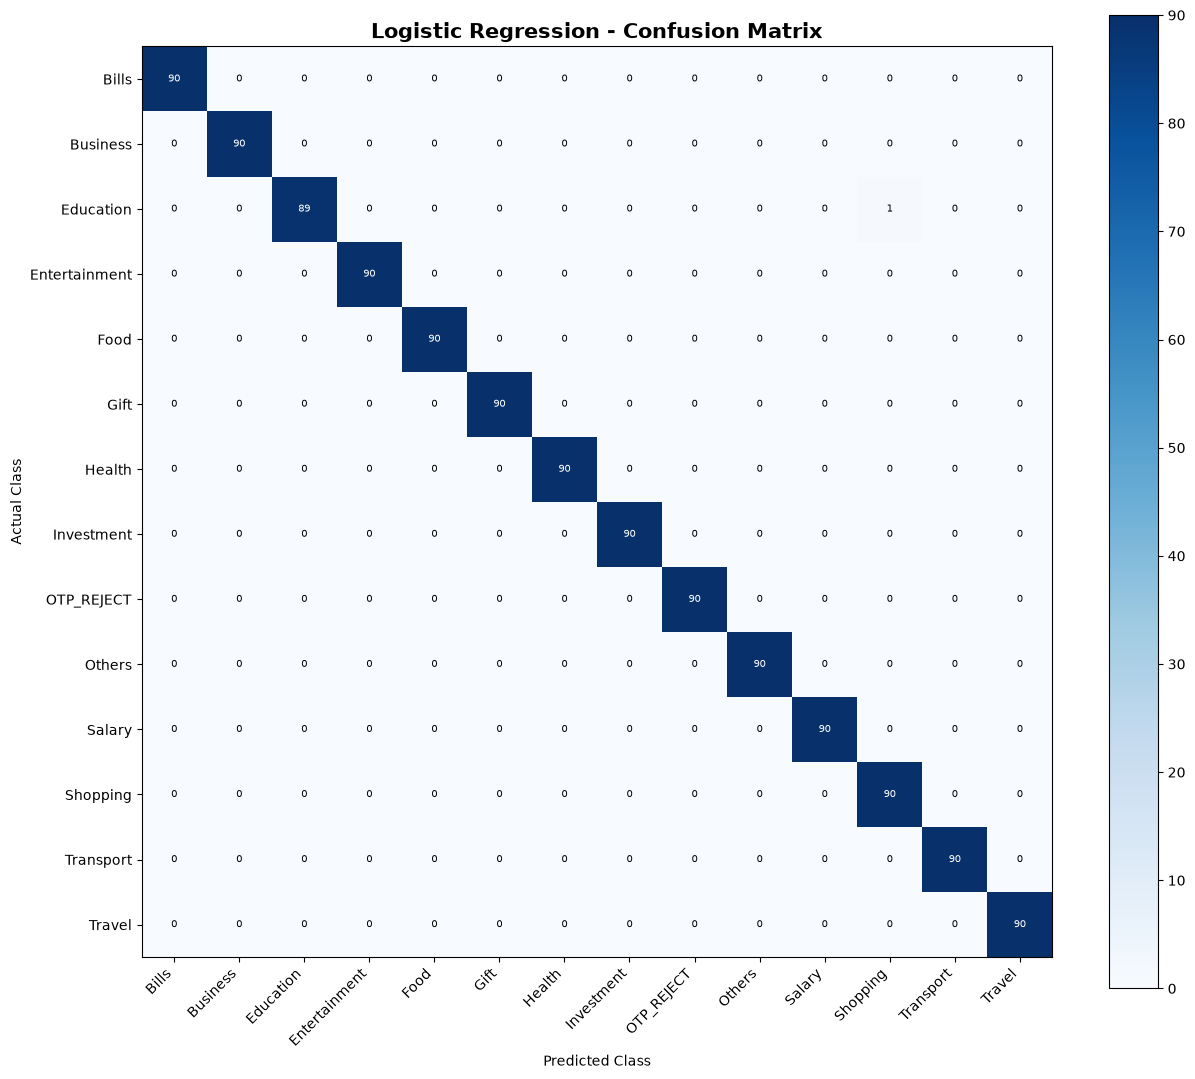

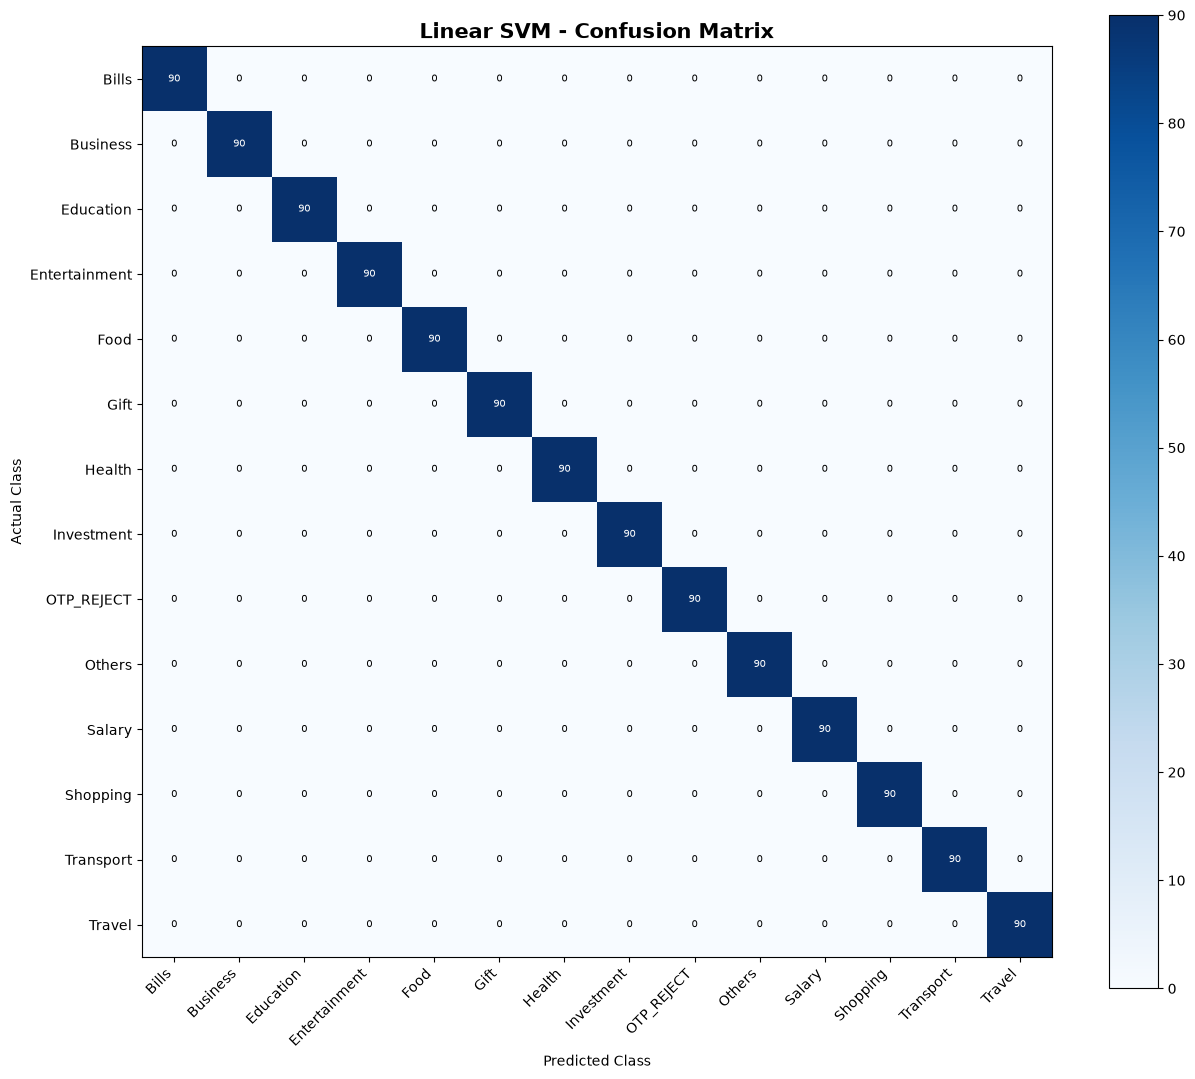

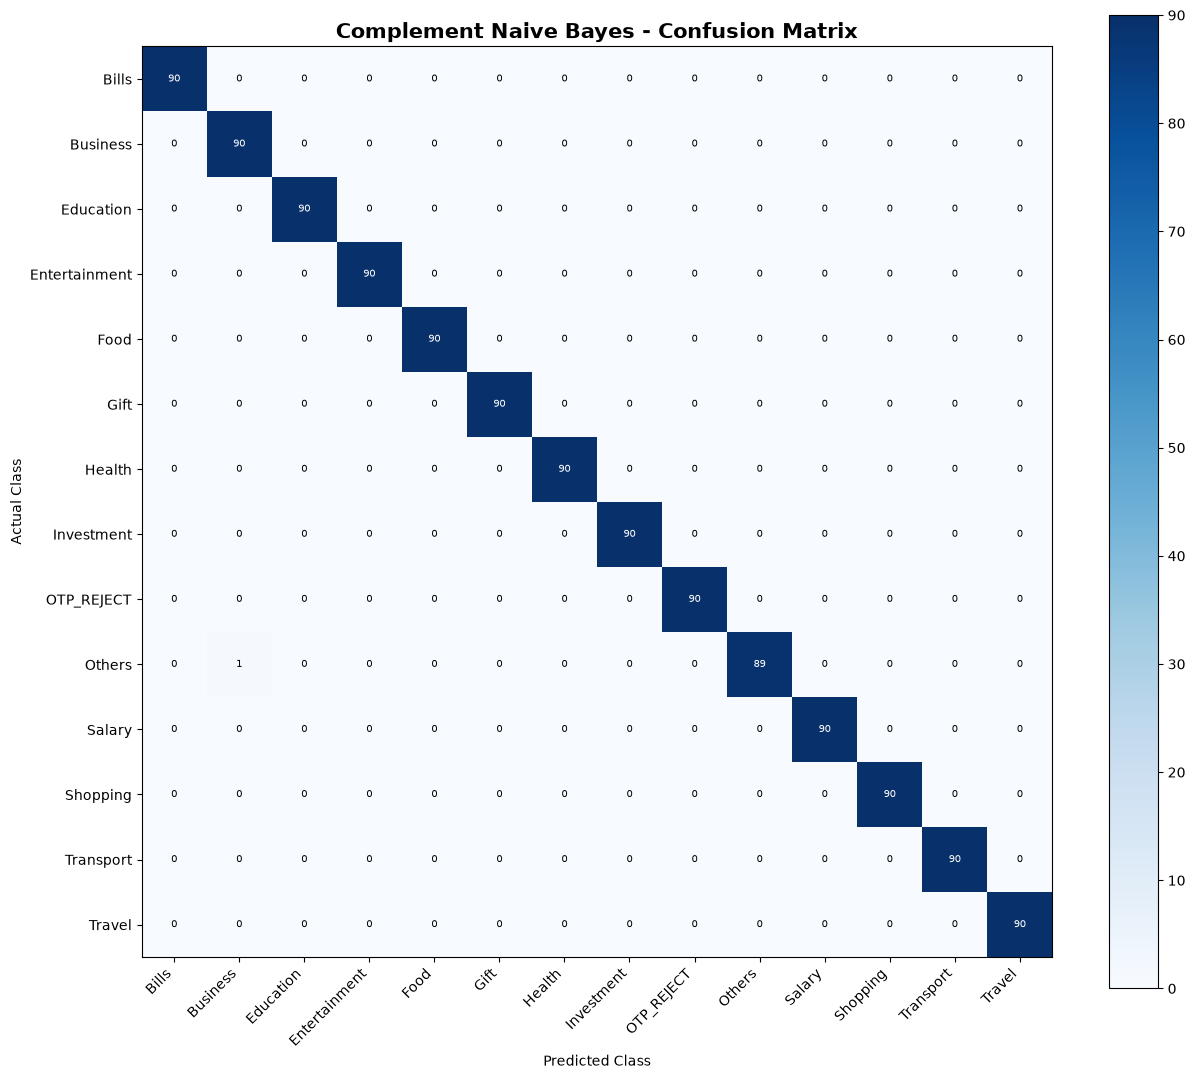

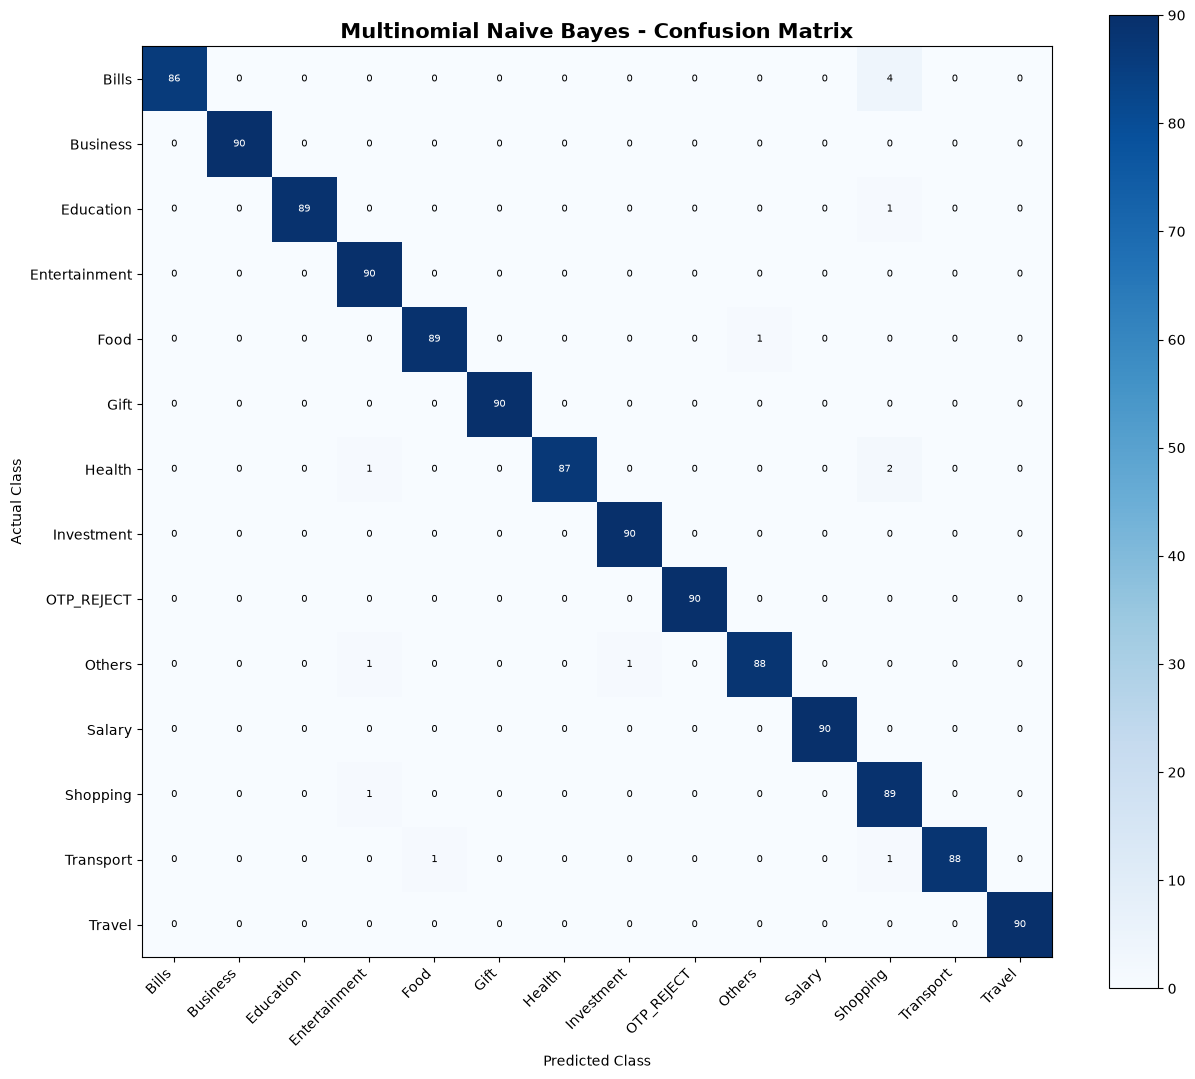

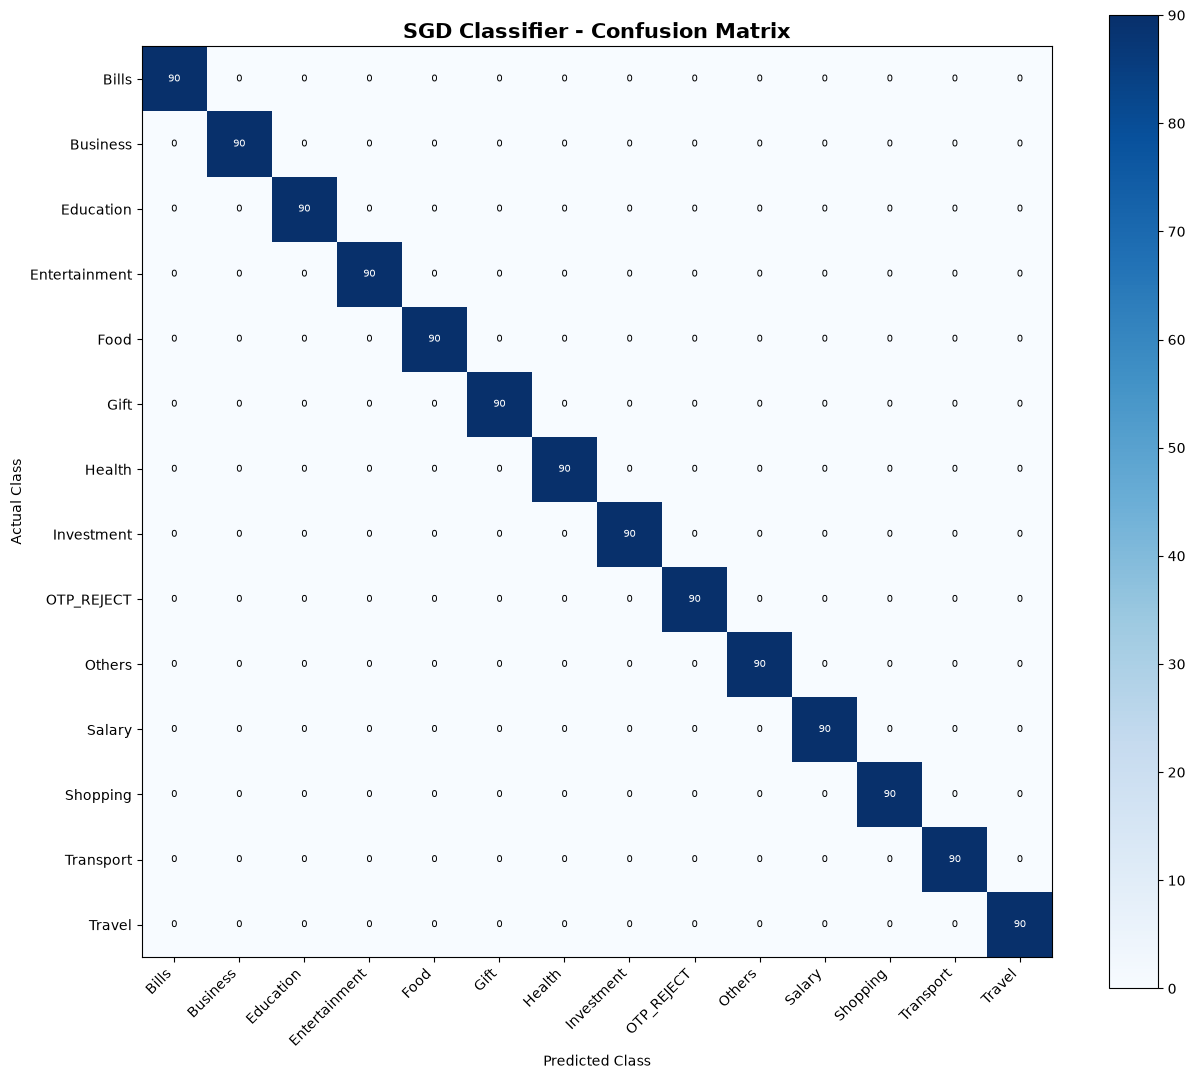

In [30]:
# ============================================================
# STEP 30 - CONFUSION MATRICES
# ============================================================

labels = sorted(
    df["Category"].unique()
)


for name, prediction in (
    test_predictions.items()
):

    cm = confusion_matrix(

        test_df[
            "Category"
        ],

        prediction,

        labels=labels
    )


    plt.figure(
        figsize=(13, 11)
    )


    plt.imshow(
        cm,
        cmap="Blues"
    )


    plt.title(
        f"{name} - Confusion Matrix",
        fontsize=15,
        fontweight="bold"
    )


    plt.xticks(
        range(len(labels)),
        labels,
        rotation=45,
        ha="right"
    )


    plt.yticks(
        range(len(labels)),
        labels
    )


    plt.xlabel(
        "Predicted Class"
    )

    plt.ylabel(
        "Actual Class"
    )


    threshold = (
        cm.max()
        / 2
    )


    for i in range(
        len(labels)
    ):

        for j in range(
            len(labels)
        ):

            plt.text(

                j,
                i,

                cm[i, j],

                ha="center",
                va="center",

                fontsize=7,

                color=(
                    "white"
                    if cm[i, j] > threshold
                    else "black"
                )
            )


    plt.colorbar()

    plt.tight_layout()


    safe_name = (
        name.lower()
        .replace(
            " ",
            "_"
        )
    )


    path = (

        FIGURE_DIR
        /
        f"{safe_name}_confusion_matrix.png"
    )


    plt.savefig(
        path,
        dpi=300,
        bbox_inches="tight"
    )


    plt.show()

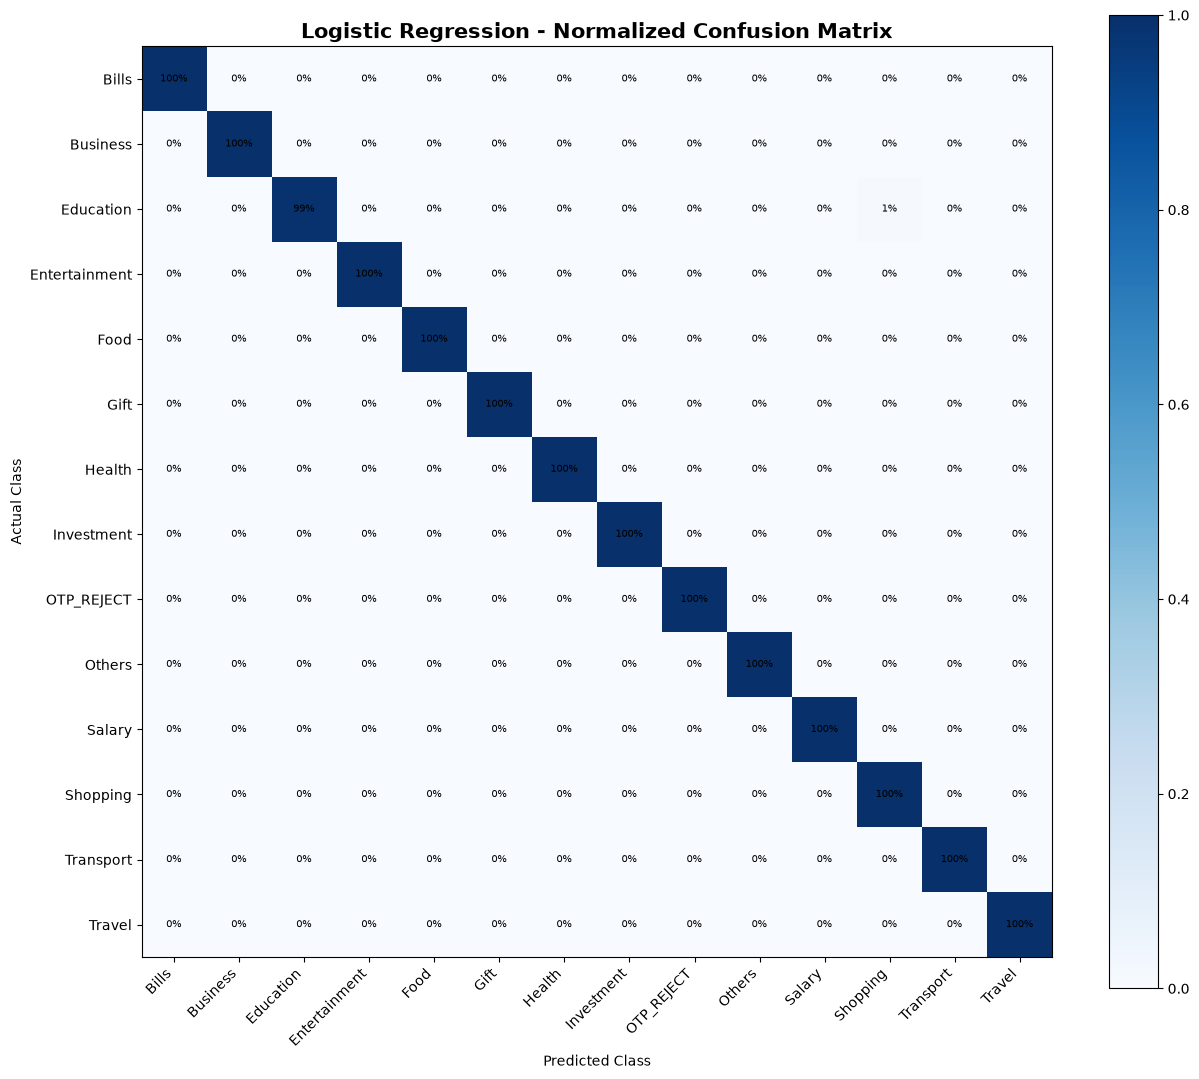

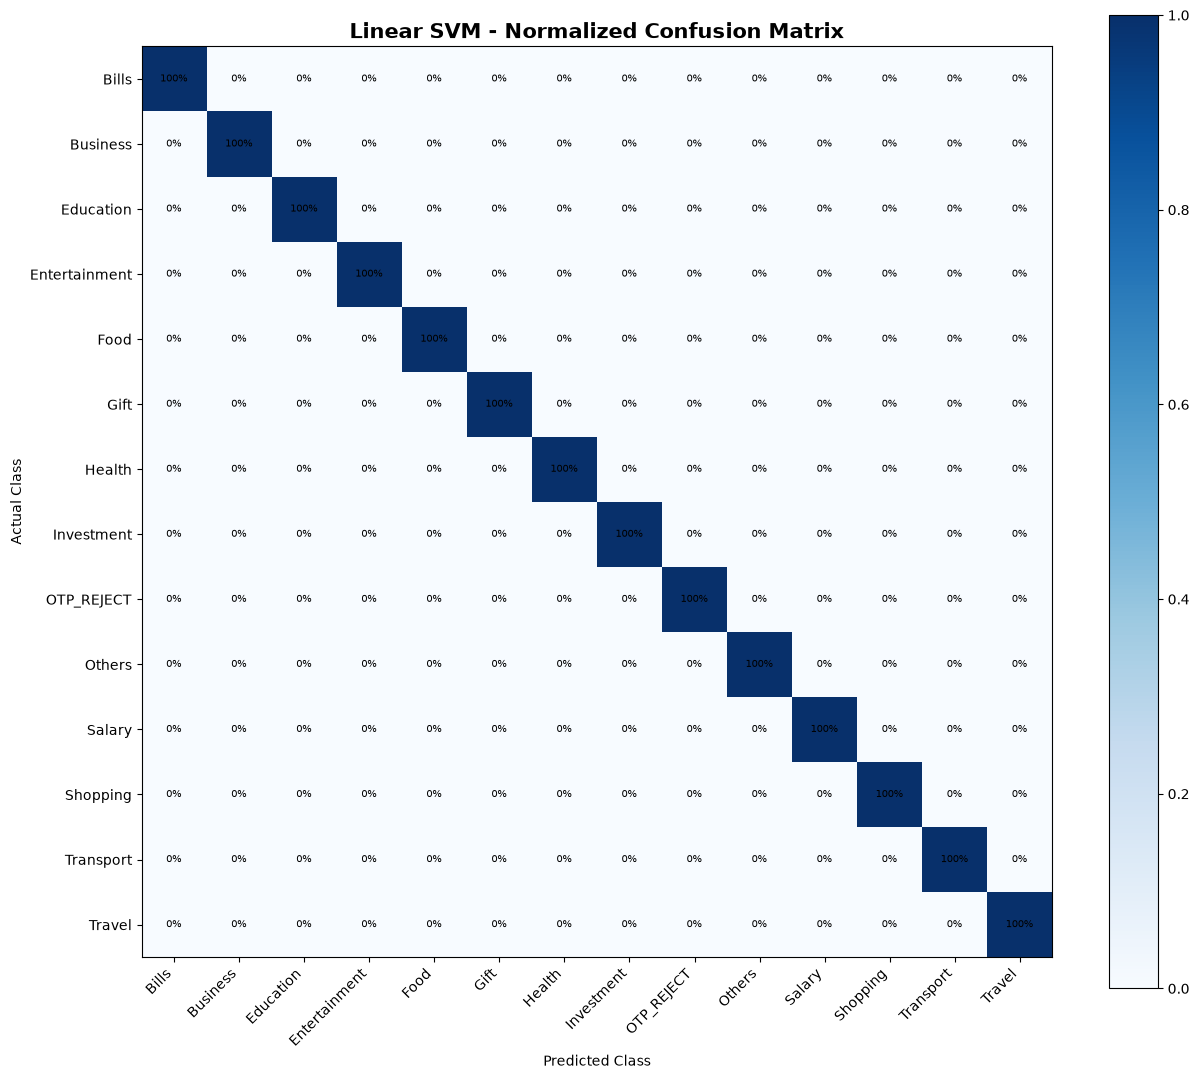

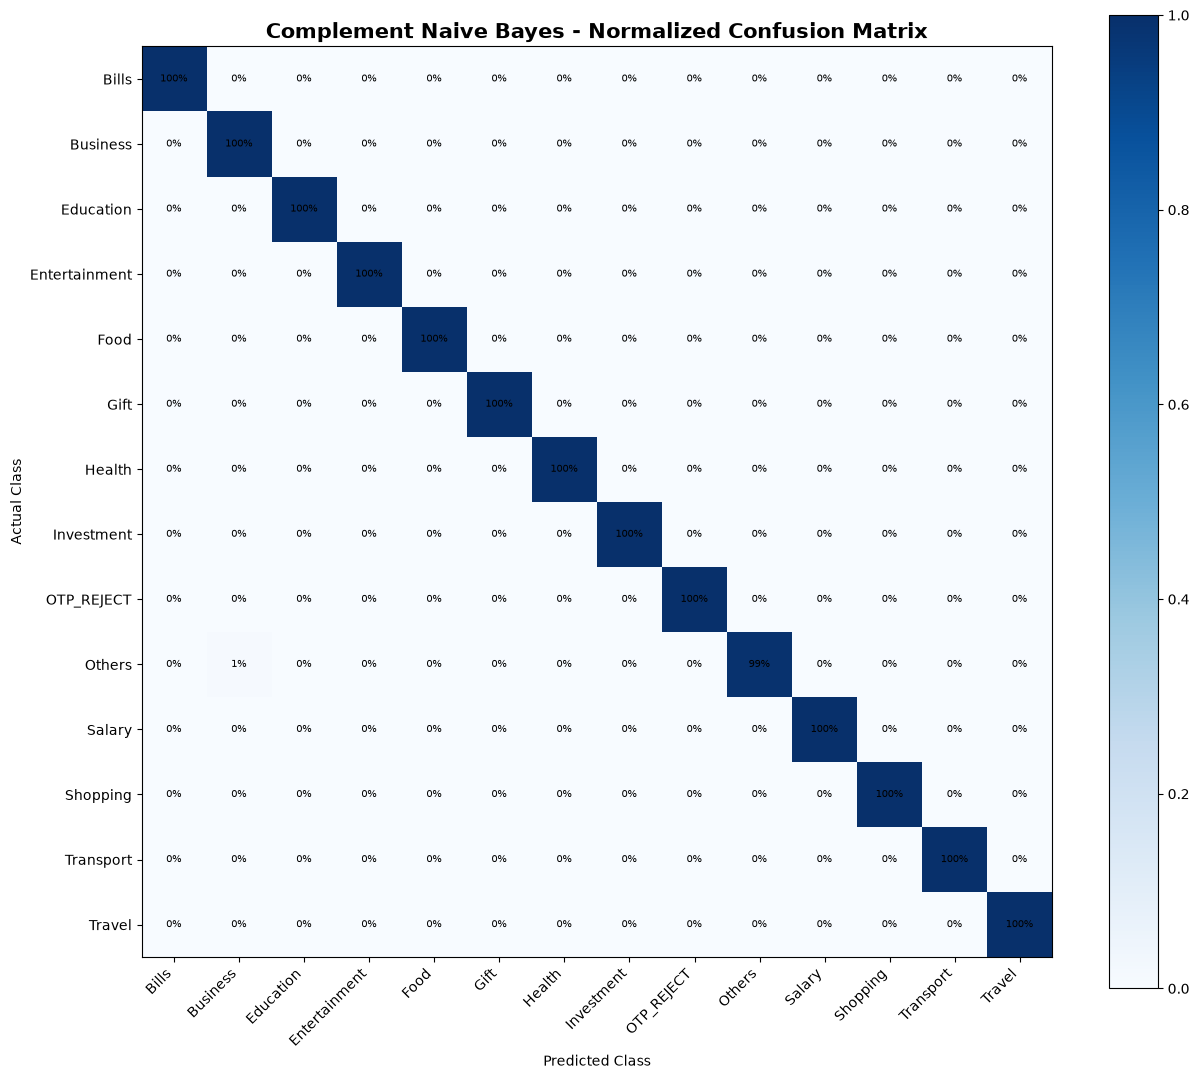

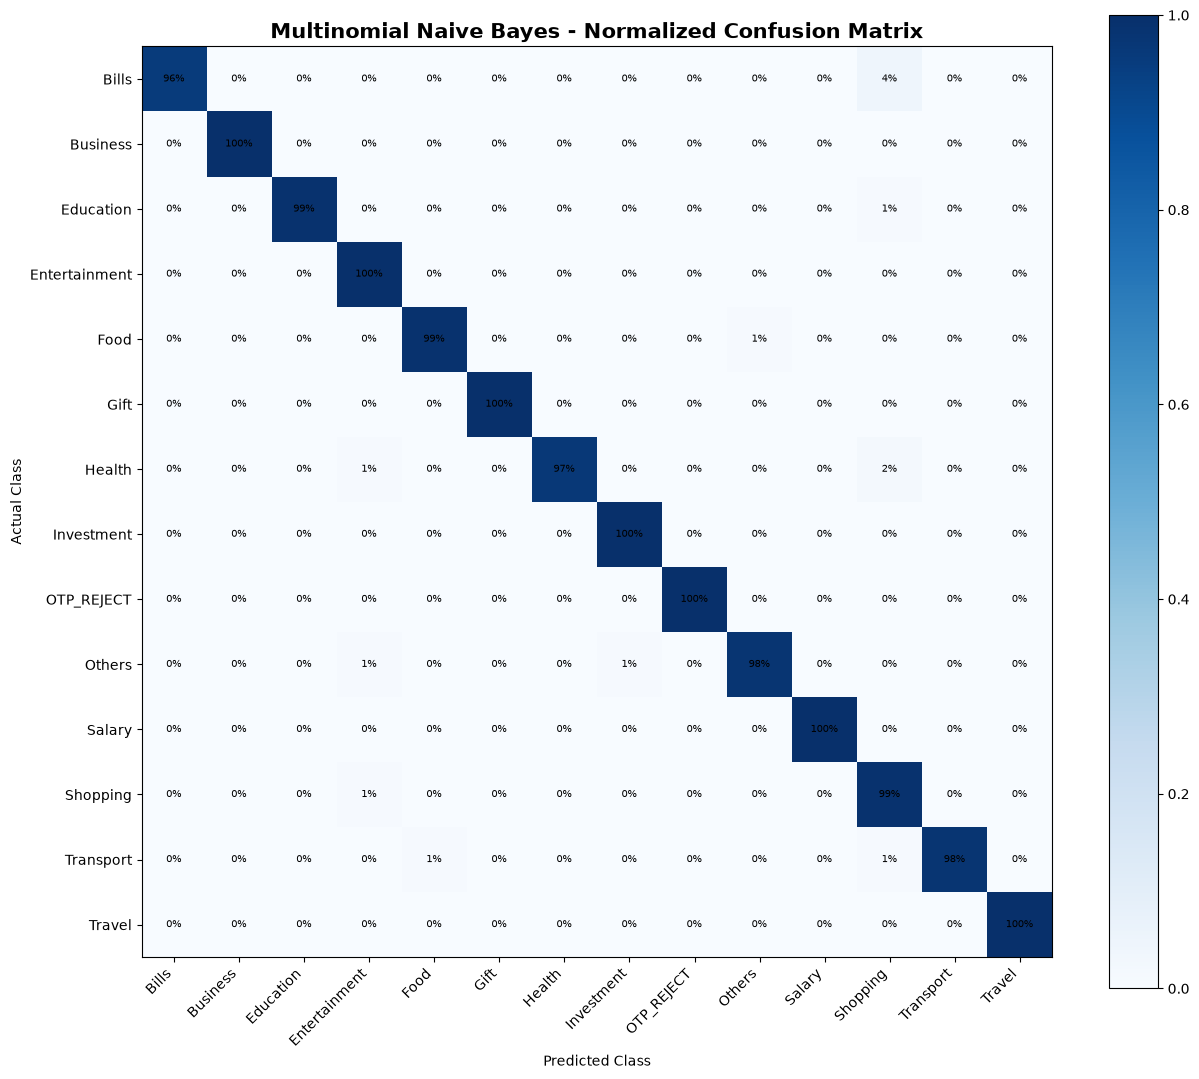

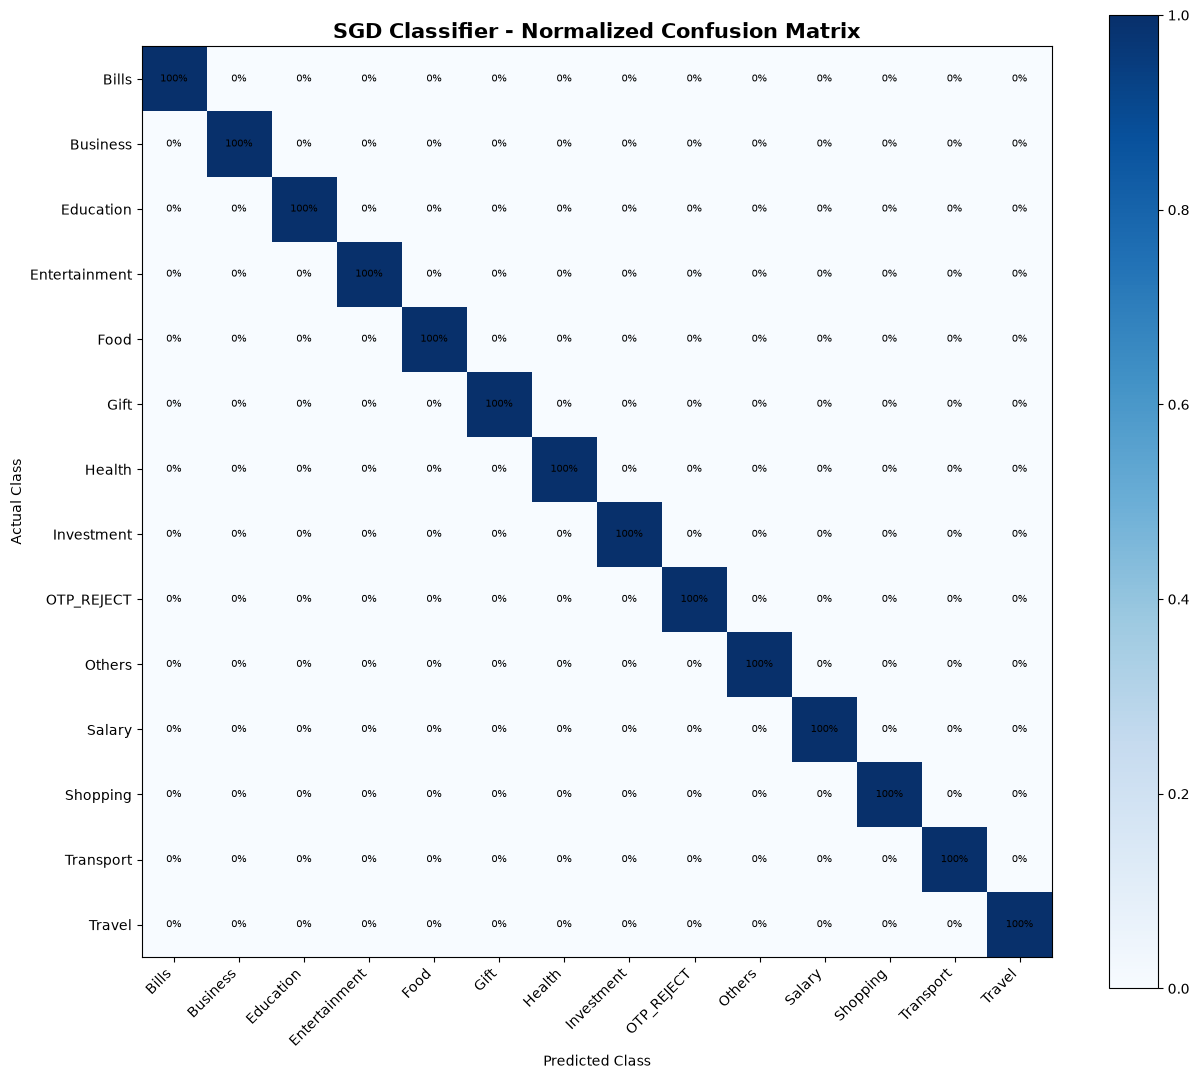

In [31]:
# ============================================================
# STEP 31 - NORMALIZED CONFUSION MATRICES
# ============================================================

for name, prediction in (
    test_predictions.items()
):

    cm = confusion_matrix(

        test_df["Category"],

        prediction,

        labels=labels,

        normalize="true"
    )


    plt.figure(
        figsize=(13, 11)
    )


    plt.imshow(
        cm,
        cmap="Blues",
        vmin=0,
        vmax=1
    )


    plt.title(
        f"{name} - Normalized Confusion Matrix",
        fontsize=15,
        fontweight="bold"
    )


    plt.xticks(
        range(len(labels)),
        labels,
        rotation=45,
        ha="right"
    )


    plt.yticks(
        range(len(labels)),
        labels
    )


    plt.xlabel(
        "Predicted Class"
    )

    plt.ylabel(
        "Actual Class"
    )


    for i in range(
        len(labels)
    ):

        for j in range(
            len(labels)
        ):

            plt.text(

                j,
                i,

                f"{cm[i, j] * 100:.0f}%",

                ha="center",
                va="center",

                fontsize=7
            )


    plt.colorbar()

    plt.tight_layout()


    safe_name = (
        name.lower()
        .replace(
            " ",
            "_"
        )
    )


    path = (

        FIGURE_DIR
        /
        f"{safe_name}_normalized_confusion_matrix.png"
    )


    plt.savefig(
        path,
        dpi=300,
        bbox_inches="tight"
    )


    plt.show()

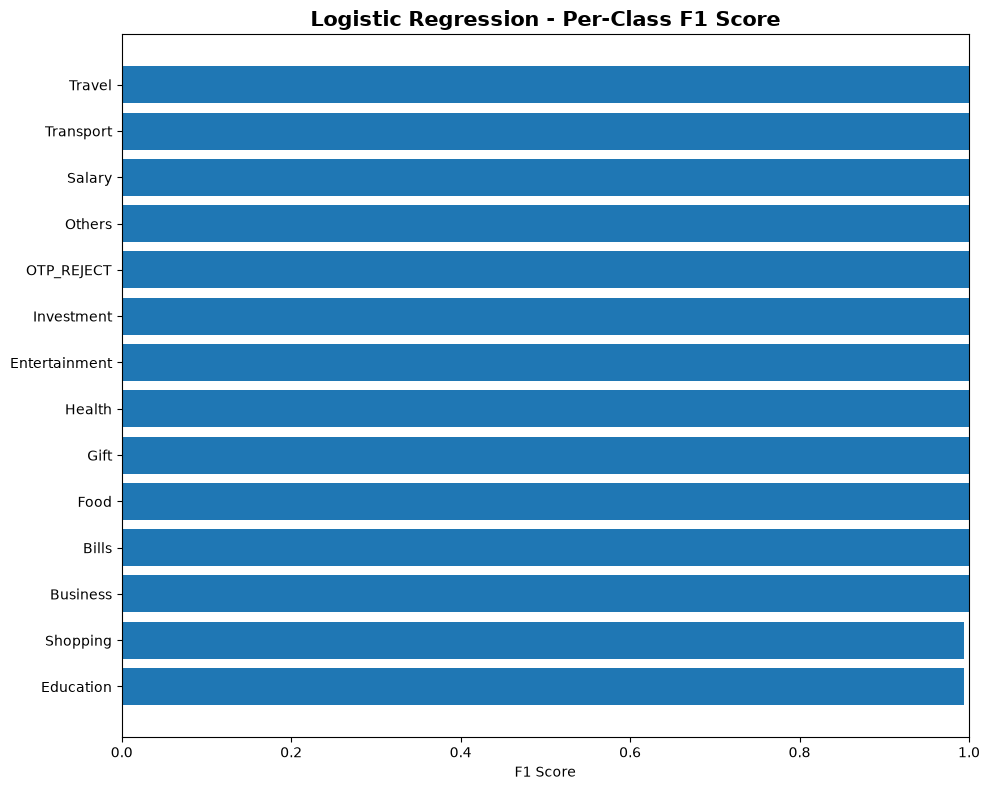

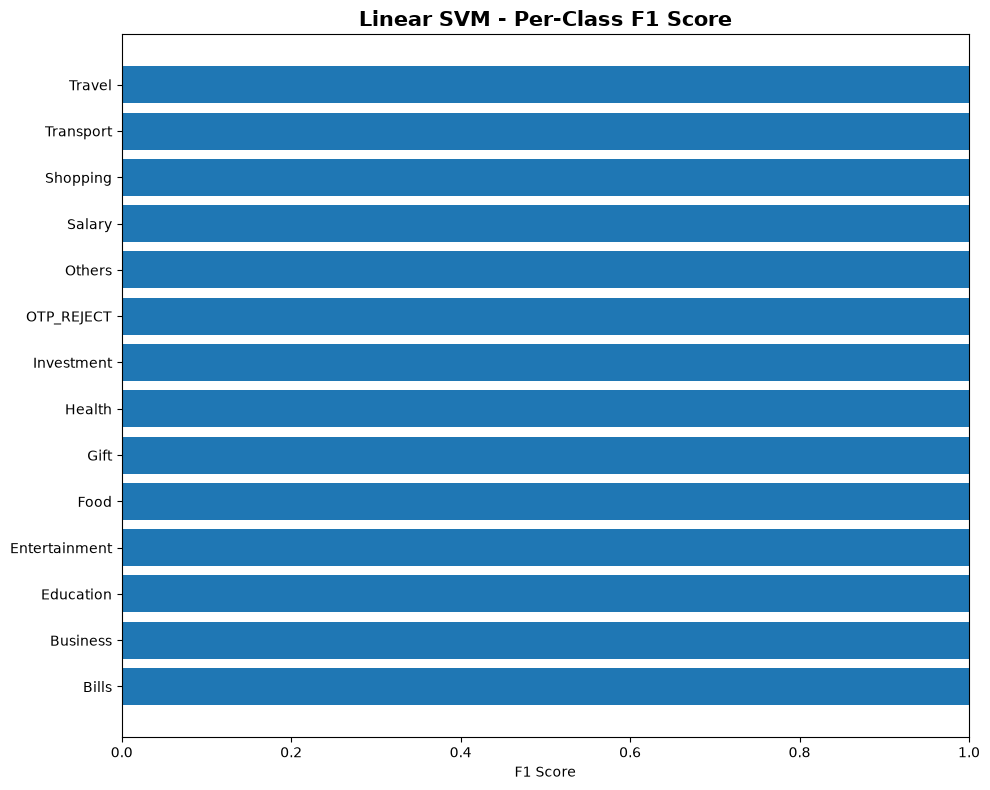

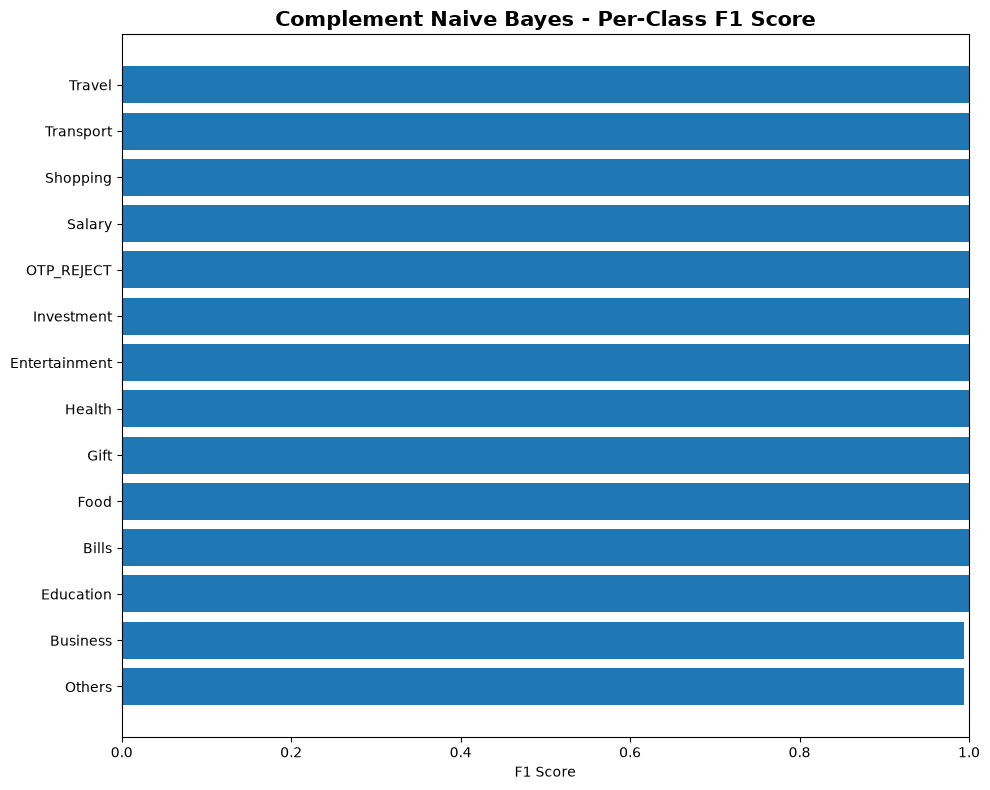

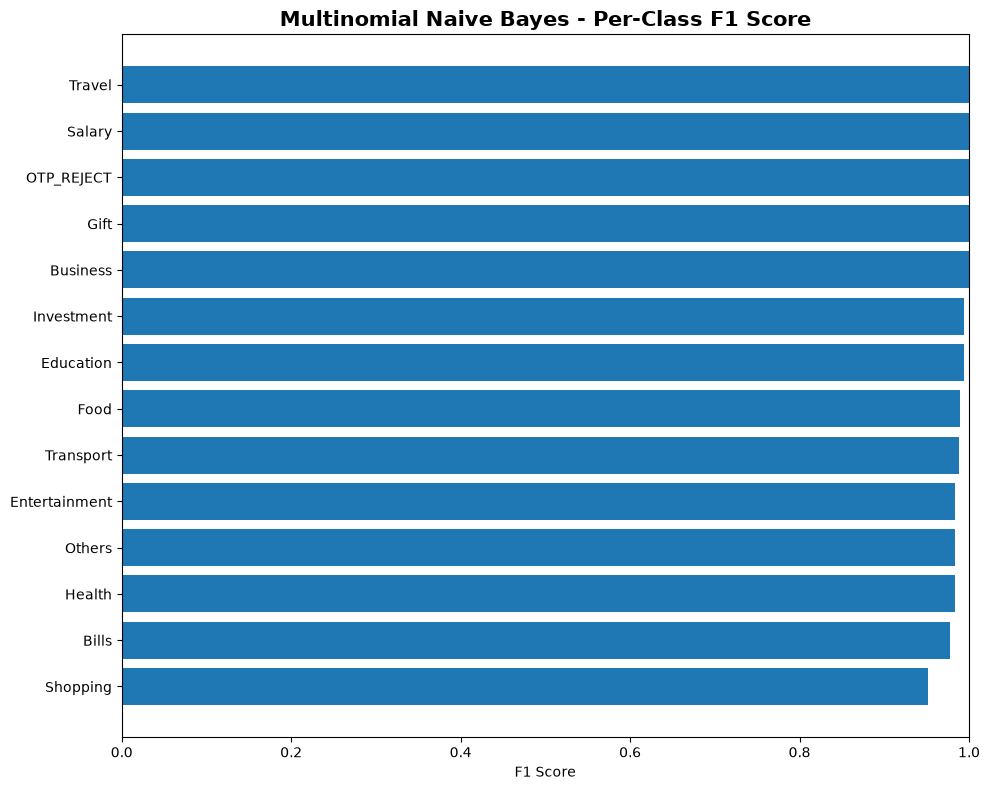

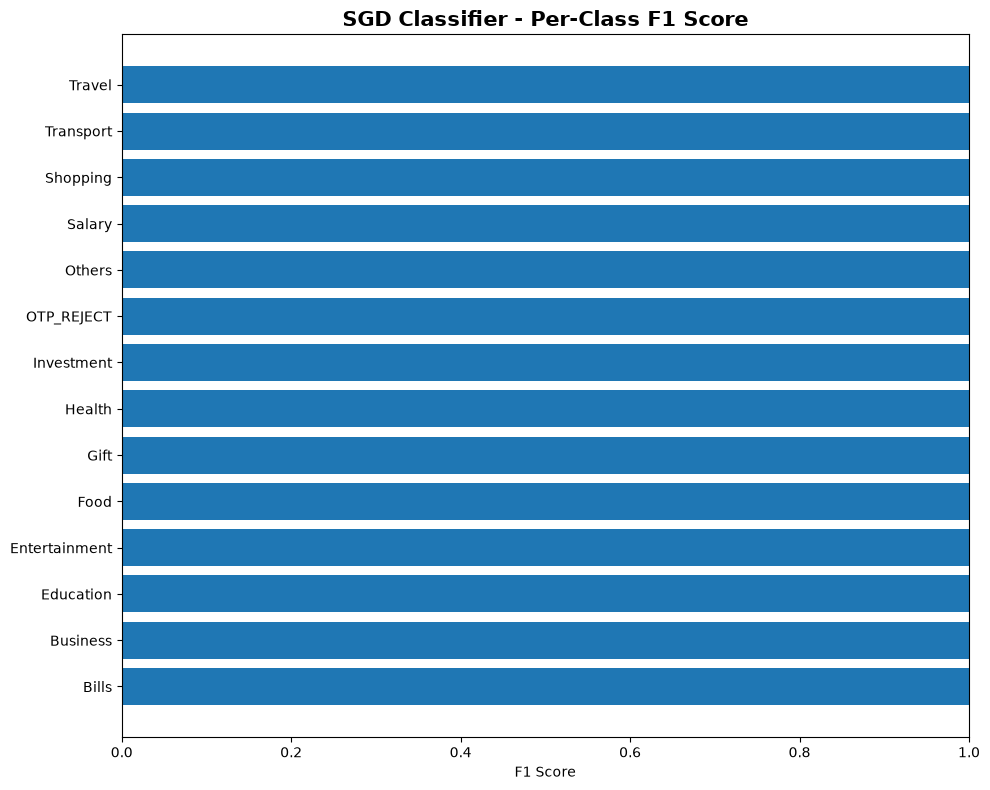

In [32]:
# ============================================================
# STEP 32 - PER-CLASS F1 SCORE GRAPHS
# ============================================================

for name, report in (
    test_reports.items()
):

    rows = []


    for category in labels:

        rows.append({

            "Category":
                category,

            "F1":
                report[
                    category
                ]["f1-score"]
        })


    category_df = (

        pd.DataFrame(
            rows
        )

        .sort_values(
            "F1"
        )
    )


    plt.figure(
        figsize=(10, 8)
    )


    plt.barh(

        category_df[
            "Category"
        ],

        category_df[
            "F1"
        ]
    )


    plt.title(
        f"{name} - Per-Class F1 Score",
        fontsize=15,
        fontweight="bold"
    )


    plt.xlabel(
        "F1 Score"
    )


    plt.xlim(
        0,
        1
    )


    plt.tight_layout()


    safe_name = (
        name.lower()
        .replace(
            " ",
            "_"
        )
    )


    path = (

        FIGURE_DIR
        /
        f"{safe_name}_class_f1.png"
    )


    plt.savefig(
        path,
        dpi=300,
        bbox_inches="tight"
    )


    plt.show()

In [33]:
# ============================================================
# STEP 33 - FINAL FIVE-ALGORITHM COMPARISON
# ============================================================

validation_summary = (

    validation_results_df[
        [
            "Algorithm",
            "Train Accuracy",
            "Validation Accuracy",
            "Macro F1",
            "Weighted F1",
            "Training Time (sec)"
        ]
    ]

    .rename(
        columns={
            "Macro F1":
                "Validation Macro F1",

            "Weighted F1":
                "Validation Weighted F1"
        }
    )
)


test_summary = (

    test_results_df[
        [
            "Algorithm",
            "Test Accuracy",
            "Macro F1",
            "Weighted F1",
            "Test Error Rate"
        ]
    ]

    .rename(
        columns={
            "Macro F1":
                "Test Macro F1",

            "Weighted F1":
                "Test Weighted F1"
        }
    )
)


final_comparison = (

    validation_summary

    .merge(
        test_summary,
        on="Algorithm"
    )

    .merge(
        otp_performance_df[
            [
                "Algorithm",
                "OTP F1"
            ]
        ],
        on="Algorithm"
    )
)


print("=" * 70)
print("FINAL FIVE-ALGORITHM COMPARISON")
print("=" * 70)


display(
    final_comparison.round(2)
)


final_comparison.to_csv(

    REPORT_DIR
    / "final_5_algorithm_comparison.csv",

    index=False
)

FINAL FIVE-ALGORITHM COMPARISON


,Algorithm,Train Accuracy,Validation Accuracy,Validation Macro F1,Validation Weighted F1,Training Time (sec),Test Accuracy,Test Macro F1,Test Weighted F1,Test Error Rate,OTP F1
0,Linear SVM,100.00,99.84,99.84,99.84,1.58,100.00,100.00,100.00,0.00,100.0
1,SGD Classifier,100.00,99.84,99.84,99.84,0.68,100.00,100.00,100.00,0.00,100.0
2,Logistic Regression,99.95,99.52,99.52,99.52,2.03,99.92,99.92,99.92,0.08,100.0
3,Complement Naive Bayes,99.81,99.52,99.52,99.52,0.45,99.92,99.92,99.92,0.08,100.0
4,Multinomial Naive Bayes,99.35,98.25,98.26,98.26,0.44,98.89,98.90,98.90,1.11,100.0


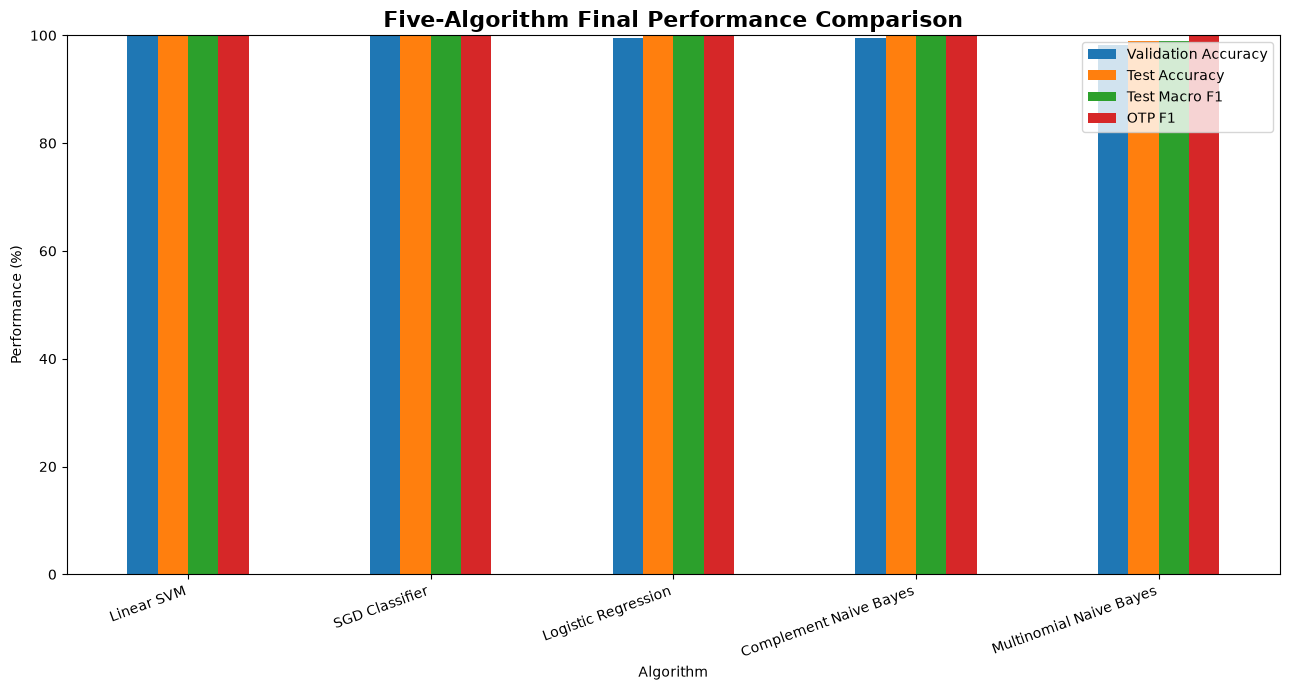

In [34]:
# ============================================================
# STEP 34 - FINAL MODEL COMPARISON GRAPH
# ============================================================

graph_df = (

    final_comparison

    .set_index(
        "Algorithm"
    )

    [
        [
            "Validation Accuracy",
            "Test Accuracy",
            "Test Macro F1",
            "OTP F1"
        ]
    ]
)


graph_df.plot(

    kind="bar",

    figsize=(13, 7)
)


plt.title(
    "Five-Algorithm Final Performance Comparison",
    fontsize=16,
    fontweight="bold"
)


plt.ylabel(
    "Performance (%)"
)


plt.ylim(
    0,
    100
)


plt.xticks(
    rotation=20,
    ha="right"
)


plt.tight_layout()


path = (
    FIGURE_DIR
    / "10_final_5_algorithm_comparison.png"
)


plt.savefig(
    path,
    dpi=300,
    bbox_inches="tight"
)


plt.show()

In [35]:
# ============================================================
# STEP 35 - SAVE ALL MODELS
# ============================================================

model_file_names = {

    "Logistic Regression":
        "logistic_regression.joblib",

    "Linear SVM":
        "linear_svm.joblib",

    "Complement Naive Bayes":
        "complement_naive_bayes.joblib",

    "Multinomial Naive Bayes":
        "multinomial_naive_bayes.joblib",

    "SGD Classifier":
        "sgd_classifier.joblib"
}


for name, model in (
    trained_models.items()
):

    path = (

        MODEL_DIR
        /
        model_file_names[
            name
        ]
    )


    joblib.dump(
        model,
        path
    )


    print(
        "Saved:",
        path
    )

Saved: C:\Users\LENOVO\Desktop\Classification_Model\models\logistic_regression.joblib
Saved: C:\Users\LENOVO\Desktop\Classification_Model\models\linear_svm.joblib
Saved: C:\Users\LENOVO\Desktop\Classification_Model\models\complement_naive_bayes.joblib
Saved: C:\Users\LENOVO\Desktop\Classification_Model\models\multinomial_naive_bayes.joblib
Saved: C:\Users\LENOVO\Desktop\Classification_Model\models\sgd_classifier.joblib


In [36]:
# ============================================================
# STEP 36 - SAVE BEST BASELINE MODEL
# ============================================================

BEST_MODEL_PATH = (

    MODEL_DIR
    /
    "best_baseline_expense_category_model.joblib"
)


joblib.dump(
    best_model,
    BEST_MODEL_PATH
)


print("=" * 70)
print("BEST BASELINE MODEL SAVED")
print("=" * 70)

print(
    "\nSelected Algorithm:",
    best_model_name
)

print(
    "\nSaved:",
    BEST_MODEL_PATH
)

BEST BASELINE MODEL SAVED

Selected Algorithm: Linear SVM

Saved: C:\Users\LENOVO\Desktop\Classification_Model\models\best_baseline_expense_category_model.joblib


In [37]:
# ============================================================
# STEP 37 - BEST MODEL FINAL TEST SUMMARY
# ============================================================

best_test_row = (

    test_results_df[
        test_results_df[
            "Algorithm"
        ]
        ==
        best_model_name
    ]

    .iloc[0]
)


best_otp_row = (

    otp_performance_df[
        otp_performance_df[
            "Algorithm"
        ]
        ==
        best_model_name
    ]

    .iloc[0]
)


print("=" * 70)
print("SELECTED MODEL - FINAL PERFORMANCE")
print("=" * 70)

print(
    "\nAlgorithm:",
    best_model_name
)

print(
    "\nTest Accuracy:",
    f"{best_test_row['Test Accuracy']:.2f}%"
)

print(
    "Macro Precision:",
    f"{best_test_row['Macro Precision']:.2f}%"
)

print(
    "Macro Recall:",
    f"{best_test_row['Macro Recall']:.2f}%"
)

print(
    "Macro F1:",
    f"{best_test_row['Macro F1']:.2f}%"
)

print(
    "Weighted F1:",
    f"{best_test_row['Weighted F1']:.2f}%"
)

print(
    "\nOTP_REJECT Precision:",
    f"{best_otp_row['OTP Precision']:.2f}%"
)

print(
    "OTP_REJECT Recall:",
    f"{best_otp_row['OTP Recall']:.2f}%"
)

print(
    "OTP_REJECT F1:",
    f"{best_otp_row['OTP F1']:.2f}%"
)

SELECTED MODEL - FINAL PERFORMANCE

Algorithm: Linear SVM

Test Accuracy: 100.00%
Macro Precision: 100.00%
Macro Recall: 100.00%
Macro F1: 100.00%
Weighted F1: 100.00%

OTP_REJECT Precision: 100.00%
OTP_REJECT Recall: 100.00%
OTP_REJECT F1: 100.00%


In [38]:
# ============================================================
# STEP 38 - SAVE EXPERIMENT METADATA
# ============================================================

metadata = {

    "dataset":
        DATA_FILE.name,

    "total_rows":
        int(len(df)),

    "transaction_categories":
        13,

    "rejection_classes":
        [
            "OTP_REJECT"
        ],

    "total_output_classes":
        int(
            df["Category"].nunique()
        ),

    "train_rows":
        int(len(train_df)),

    "validation_rows":
        int(len(val_df)),

    "test_rows":
        int(len(test_df)),

    "split_method":
        "Category-preserving template-aware 70/15/15 split",

    "feature_extraction":
        "TF-IDF",

    "ngram_range":
        [
            1,
            2
        ],

    "max_features":
        30000,

    "algorithms":
        list(
            models.keys()
        ),

    "best_model":
        str(
            best_model_name
        ),

    "selection_method":
        "Highest validation Macro F1, then validation accuracy",

    "otp_behavior":
        "OTP_REJECT predictions are rejection outputs and must not be stored as expense transactions",

    "random_state":
        RANDOM_STATE
}


metadata_path = (

    REPORT_DIR
    /
    "experiment_metadata.json"
)


with open(
    metadata_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        metadata,
        f,
        indent=2
    )


print(
    "Metadata saved:",
    metadata_path
)

Metadata saved: C:\Users\LENOVO\Desktop\Classification_Model\reports\experiment_metadata.json


In [39]:
# ============================================================
# STEP 39 - FINAL PROJECT CHECK
# ============================================================

print("=" * 70)
print("FINAL PROJECT CHECK")
print("=" * 70)


print("\nMODELS:")

for file in sorted(
    MODEL_DIR.glob("*")
):

    print(
        "OK ",
        file.name
    )


print("\nREPORTS:")

for file in sorted(
    REPORT_DIR.glob("*")
):

    print(
        "OK ",
        file.name
    )


print("\nFIGURES:")

for file in sorted(
    FIGURE_DIR.glob("*")
):

    print(
        "OK ",
        file.name
    )


print("\nSPLITS:")

for file in sorted(
    SPLIT_DIR.glob("*")
):

    print(
        "OK ",
        file.name
    )


print("\n" + "=" * 70)

print(
    "FIVE-MODEL BASELINE EXPERIMENT COMPLETE"
)

print("=" * 70)

FINAL PROJECT CHECK

MODELS:
OK  best_baseline_expense_category_model.joblib
OK  complement_naive_bayes.joblib
OK  linear_svm.joblib
OK  logistic_regression.joblib
OK  multinomial_naive_bayes.joblib
OK  sgd_classifier.joblib

REPORTS:
OK  complement_naive_bayes_classification_report.csv
OK  dataset_summary.csv
OK  experiment_metadata.json
OK  final_5_algorithm_comparison.csv
OK  final_test_results.csv
OK  linear_svm_classification_report.csv
OK  logistic_regression_classification_report.csv
OK  multinomial_naive_bayes_classification_report.csv
OK  otp_reject_performance.csv
OK  sgd_classifier_classification_report.csv
OK  split_class_distribution.csv
OK  validation_model_comparison.csv

FIGURES:
OK  01_category_distribution.png
OK  02_split_distribution.png
OK  03_validation_accuracy.png
OK  04_validation_error_rate.png
OK  05_train_vs_validation_accuracy.png
OK  06_validation_precision_recall_f1.png
OK  07_test_accuracy.png
OK  08_test_error_rate.png
OK  10_final_5_algorithm_compariso